# Hackathon Hi! Paris (Group 46) : PISA dataset analysis

In [1]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

#### Loading the dataset

In [91]:
df = pd.read_csv("X_train.csv")
df.describe()

,Unnamed: 0,Year,CNTRYID,CNTSCHID,CNTSTUID,NatCen,SUBNATIO,OECD,ADMINMODE,LANGTEST_QQQ,...,science_q10_total_timing,science_q11_total_timing,science_q12_total_timing,science_q13_total_timing,science_q14_total_timing,science_q15_total_timing,science_q16_total_timing,science_q17_total_timing,science_q18_total_timing,science_q19_total_timing
count,1.172086e+06,1.172086e+06,1.172086e+06,1.172086e+06,1.172086e+06,1.172086e+06,1.172086e+06,1.172086e+06,1.172086e+06,1.156728e+06,...,3.307340e+05,2.221060e+05,4.514500e+04,1.000000,1.0,1.0,1.0,1.00,1.000000,1.00
mean,8.788127e+05,2.018517e+03,4.494376e+02,4.494433e+07,4.492926e+07,4.321244e+04,4.437437e+06,5.213278e-01,1.912332e+00,3.136003e+02,...,6.442787e+04,6.821547e+04,4.255167e+04,73159.335938,47928.5,53570.5,118881.0,119068.25,167551.796875,59299.25
std,5.075340e+05,2.835234e+00,2.729180e+02,2.729202e+07,2.726077e+07,2.583040e+04,2.655083e+06,5.403367e-01,2.828123e-01,1.556093e+02,...,5.484239e+04,8.608163e+04,3.316757e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000e+00,2.015000e+03,8.000000e+00,8.000010e+05,8.000010e+05,8.000000e+02,8.000000e+04,0.000000e+00,1.000000e+00,1.130000e+02,...,3.267500e+02,4.502000e+02,4.686000e+02,73159.335938,47928.5,53570.5,118881.0,119068.25,167551.796875,59299.25
25%,4.390612e+05,2.015000e+03,2.030000e+02,2.030036e+07,2.030966e+07,1.910000e+04,2.030000e+06,0.000000e+00,2.000000e+00,1.560000e+02,...,4.120906e+04,4.287625e+04,2.255100e+04,73159.335938,47928.5,53570.5,118881.0,119068.25,167551.796875,59299.25
50%,8.787835e+05,2.018000e+03,4.110000e+02,4.110018e+07,4.110402e+07,4.100000e+04,4.110000e+06,1.000000e+00,2.000000e+00,3.130000e+02,...,5.935129e+04,6.240938e+04,4.053520e+04,73159.335938,47928.5,53570.5,118881.0,119068.25,167551.796875,59299.25
75%,1.318404e+06,2.022000e+03,7.030000e+02,7.030026e+07,7.030590e+07,7.020000e+04,7.030000e+06,1.000000e+00,2.000000e+00,4.420000e+02,...,8.155475e+04,8.568938e+04,5.618780e+04,73159.335938,47928.5,53570.5,118881.0,119068.25,167551.796875,59299.25
max,1.758128e+06,2.022000e+03,9.830000e+02,9.830081e+07,9.832912e+07,8.600000e+04,9.830000e+06,2.000000e+00,2.000000e+00,9.980000e+02,...,1.550666e+07,2.483809e+07,1.336106e+06,73159.335938,47928.5,53570.5,118881.0,119068.25,167551.796875,59299.25


In [92]:
y = pd.read_csv('y_train.csv')

In [ ]:
#Our target : The concentration 

#Limits of the variable "contentration": manual selection of the most relevant variables for the concentration variable, 
# based on the correlation matrix and the importance of the variables in the model.

concentration = ["IC182",#usage des ressources digitales et ordinateurs
                 "PA188",#créativité, résolution de pb, joie dans l'apprentissage, etc...
                 "ST340",#identification comme étant créatif
                 "ST355",#esprit pratique et débrouillardise 
                 "ST342",#imagination, nouveauté, créativité
                 "ST343",#aider les autres
                 "ST268",#attitude face aux maths
                 "ST301",#curiosité
                 "PA033",#broad science useful to understand the world
                 "ST036",#lien école et réussite
                 "ST305",
                 "ST263",#confiance et attitude face à l'effort pour s'améliorer
]

# Other potentially relevant variables: "ST296","PA188","ST098" 

concent = df[concentration]
concent

,IC182,PA188,ST340,ST355,ST342,ST343,ST268,ST301,PA033,ST036,ST305,ST263
0,0.000000,0.000000,0.000000,0.000000,0.000000,2.0,3.000000,3.5,NaN,NaN,2.25,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.333333,NaN,0.666667
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.333333,NaN,0.666667
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.666667
...,...,...,...,...,...,...,...,...,...,...,...,...
1172081,1.666667,0.000000,3.000000,3.000000,3.000000,0.0,4.000000,0.0,NaN,NaN,0.00,NaN
1172082,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.333333,NaN,NaN,NaN
1172083,3.000000,6.333333,4.666667,4.333333,3.333333,2.5,5.666667,3.0,NaN,NaN,2.50,NaN
1172084,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,NaN,0.333333


In [ ]:
# Standardization of the concentration variable: we standardize the concentration variable to have a mean of 0 and a standard deviation of 1, which can help improve the performance of some machine learning models.
concentstd = (concent - concent.min()) / (concent.max() - concent.min())
concentstd.describe()

,IC182,PA188,ST340,ST355,ST342,ST343,ST268,ST301,PA033,ST036,ST305,ST263
count,412647.000000,412647.000000,412647.000000,412647.000000,412647.000000,412647.000000,412647.000000,412647.000000,348119.000000,411320.000000,412647.000000,411320.000000
mean,0.296465,0.086707,0.334638,0.216980,0.448630,0.381465,0.478446,0.274551,0.133889,0.719022,0.227321,0.415318
std,0.336054,0.215737,0.233382,0.221737,0.309255,0.208344,0.262893,0.144489,0.301115,0.301444,0.134526,0.324524
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.304348,0.333333,0.225000,0.000000,0.666667,0.175000,0.000000
50%,0.000000,0.000000,0.400000,0.208333,0.533333,0.434783,0.555556,0.300000,0.000000,0.777778,0.250000,0.333333
75%,0.666667,0.000000,0.500000,0.416667,0.666667,0.521739,0.666667,0.350000,0.000000,1.000000,0.300000,0.666667
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# Creation of the concentration variable: we create a new variable "concentration" by taking the mean of the standardized concentration variables, in order to better understand the concentration variable.
df["concentration"] = df["concentration"]/len(concentstd.columns)
df["concentration"].describe()

count    1.172086e+06
mean     1.170268e-01
std      1.114668e-01
min      0.000000e+00
25%      0.000000e+00
50%      9.259259e-02
75%      1.831320e-01
max      6.037138e-01
Name: concentration, dtype: float64

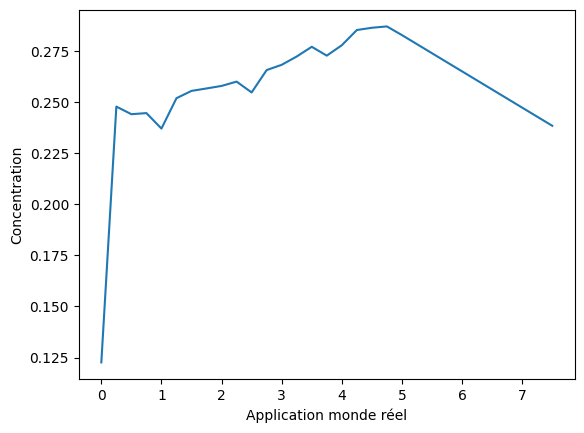

In [ ]:
# Visualization of the concentration variable: we visualize the concentration variable using a boxplot and a histogram to better understand its distribution.
df.groupby("ST283")["concentration"].mean().plot()
plt.xlabel("Application monde réel")
plt.ylabel("Concentration")
plt.show()

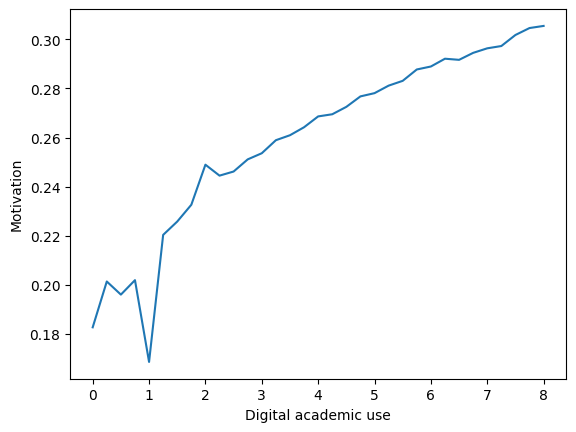

In [ ]:
df.groupby("IC176")["concentration"].mean().plot()
plt.xlabel("Digital academic use")
plt.ylabel("Motivation")
plt.show()

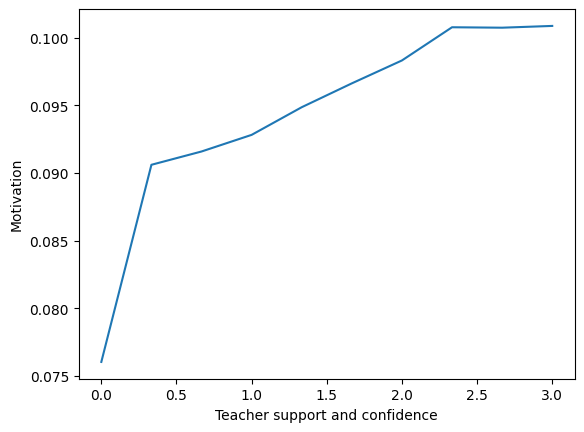

In [102]:
df.groupby("ST211")["concentration"].mean().plot()
plt.xlabel("Teacher support and confidence")
plt.ylabel("Motivation")
plt.show()

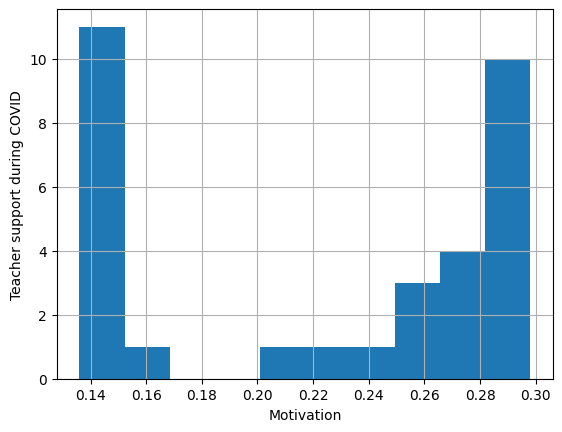

In [103]:
df.groupby("ST348")["concentration"].mean().hist()
plt.xlabel("Motivation")
plt.ylabel("Teacher support during COVID")
plt.show()

In [ ]:
# Corrélation Pearson (par défaut)
# Limits of the correlation: it only captures linear relationships and can be affected by outliers, so it's important to interpret it with caution and consider other types of relationships that may exist between the variables.
corr_pearson = df["concentration"].corr(y["MathScore"], method="pearson")
print("Corrélation Pearson concentration vs MathScore :", corr_pearson)

# Corrélation Spearman (utile si tu veux respecter l'ordre mais pas la linéarité)
# Limits of the correlation: it only captures monotonic relationships and can be affected by outliers, so it's important to interpret it with caution and consider other types of relationships that may exist between the variables.
corr_spearman = df["concentration"].corr(y["MathScore"], method="spearman")
print("Corrélation Spearman concentration vs MathScore :", corr_spearman)

Corrélation Pearson concentration vs MathScore : 0.041424137524648214
Corrélation Spearman concentration vs MathScore : 0.19804611203616987
Corrélation Spearman concentration vs MathScore : 0.19804611203616987


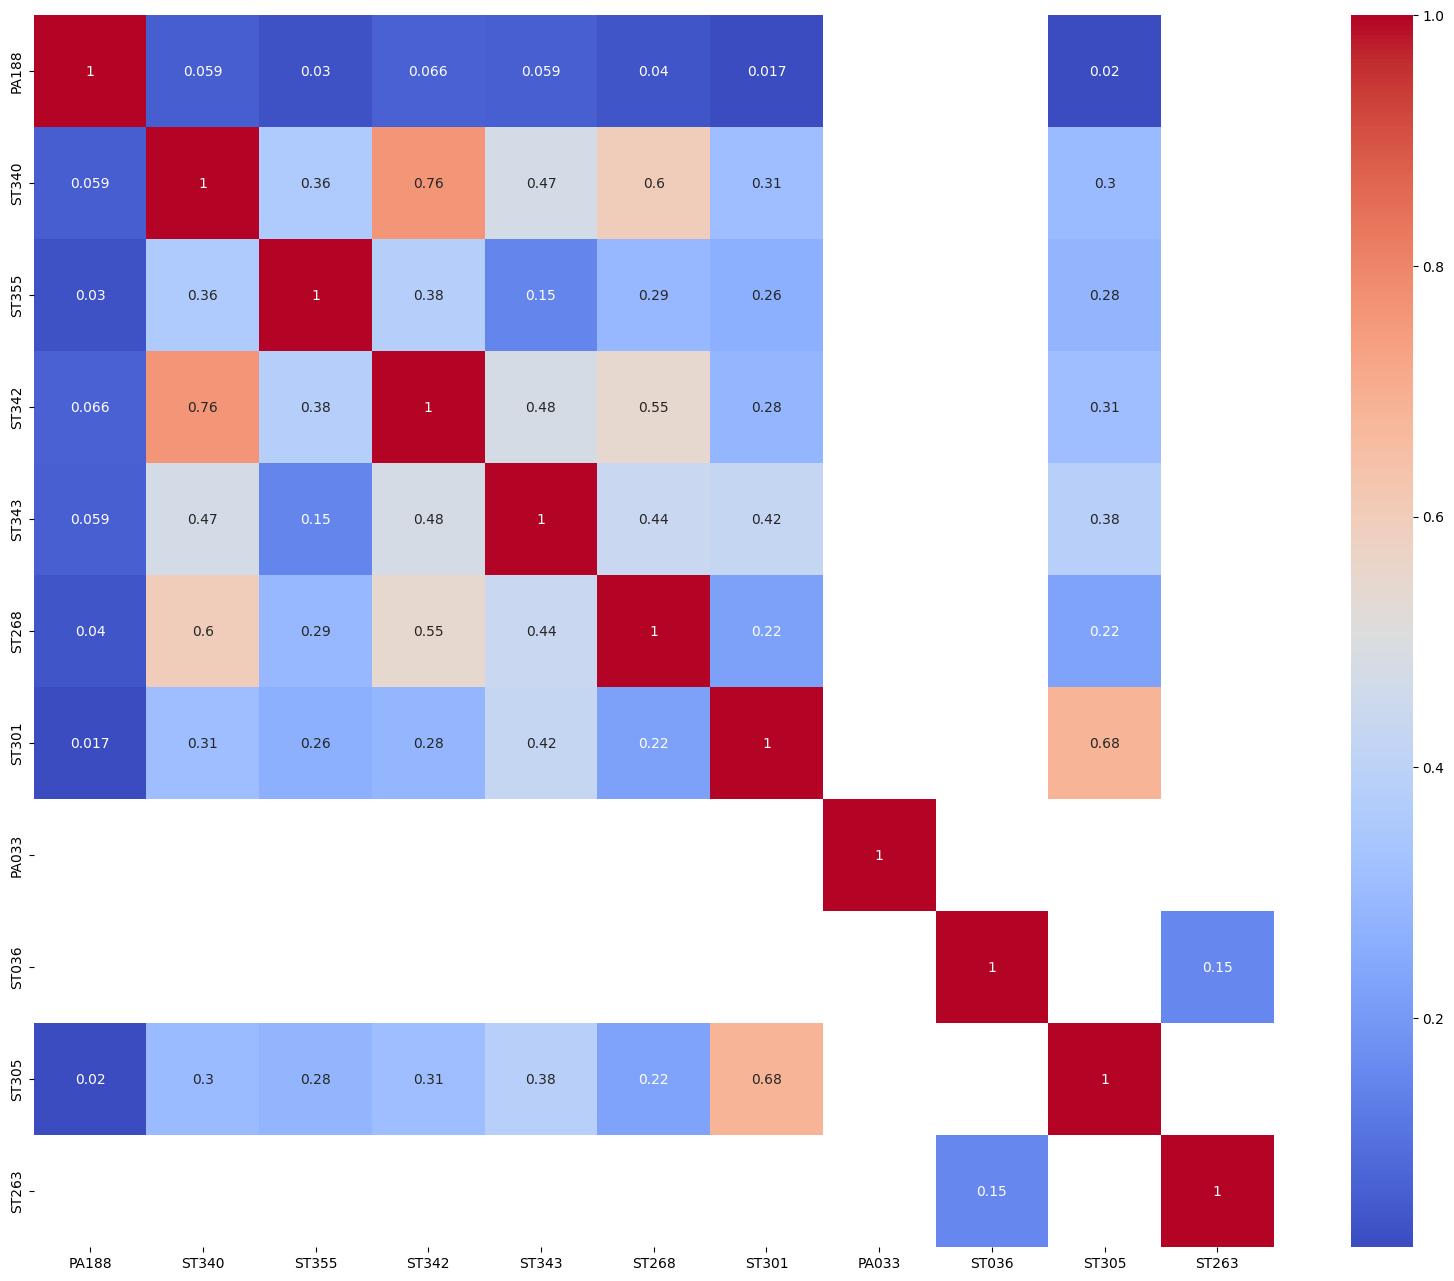

In [ ]:
# Trying to identify the correlations between the variables we choose for the concentration variable, in order to better understand the relationships between these variables and the concentration variable
plt.figure(figsize=(20,16))
corr = concentstd.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [54]:
donnees = pd.read_csv("X_train.csv")
label = df["concentration"]

In [ ]:
# All the variables in the dataset, grouped by theme
career = ["carrer","FL162","ST330","FL169","FL150","IC182","FL164","FL160","PA196","PA197","EC153","ST327","ST113","PA032"]
class_envir = ["classe_environnement","ST283","ST267","FL166","ST348","ST296","ST270","ST059","ST104","ST223","ST102","ST273","ST212","PA007","ST211","ST213","ST098","ST100","ST097"]
creativity = ["creativité","PA188","ST338","ST342","ST336","ST340"]
education_history = ["education,histoire","ST350","PA183","ST226","PA186","ST062","PA006","ST347","PA182","ST127","ST125","EC031","EC012","PA177","PA018","PA175","WB176","ST260","PA002"]
family_background = ["background famillial","ST253","ST255","ST230","PA042","ST258","ST256","ST005","ST021","ST007","FL170","WB163","FL167","ST250","ST353","WB164","ST254","PA009","PA004","PA003","ST006","ST008","ST177","PA041","PA008","PA154","ST300","ST251","ST008","ST006","PA008","ST011"]
general = ["general","Year","CNT","CNTRYID","CNTSCHID","CNTSTUID","CYC","NatCen","STRATUM","SUBNATIO","OECD","ADMINMODE","LANGTEST_QQQ","LANGTEST_COG","LANGTEST_PAQ","Option_CT","Option_FL","Option_ICTQ","Option_WBQ","Option_PQ","Option_TQ","Option_UH","BOOKID","ST001D01T","ST003D02T","ST003D03T","ST004D01T","EFFORT1","EFFORT2","OCOD1","OCOD2","OCOD3","AGE","GRADE","ISCEDP","IMMIG","COBN_S","MISSSC","MATHEASE"]
global_competence = ["global competence","PA167","PA166"]
digital_competence = ["digital_competence","IC171","IC180","IC176","IC173","IC174","ST351","IC184","IC177","IC183","IC172","IC175","ST349","ST322","IC170","ST158","IC014","IC001"]
maths_attitude = ["maths_attitude", "WB165","WB166","ST268","ST275","ST289","ST290","ST297","ST095","PA033","ST146"]
motivation = ["motivation","ST331","ST352","ST355","ST301","ST307","ST188","EC162","ST263","WB177","ST183","EC163","ST036","ST208"]
reading = ["reading","reading_q1_average_score","reading_q2_average_score","reading_q3_average_score","reading_q4_average_score","reading_q5_average_score","reading_q6_average_score","reading_q7_average_score","reading_q8_average_score","reading_q9_average_score","reading_q10_average_score","reading_q11_average_score","reading_q12_average_score","reading_q13_average_score","reading_q14_average_score","reading_q15_average_score","reading_q1_total_timing","reading_q2_total_timing","reading_q3_total_timing","reading_q4_total_timing","reading_q5_total_timing","reading_q6_total_timing","reading_q7_total_timing","reading_q8_total_timing","reading_q9_total_timing","reading_q10_total_timing","reading_q11_total_timing","reading_q12_total_timing","reading_q13_total_timing","reading_q14_total_timing","reading_q15_total_timing"]
reading_engagement = ["reading engagement", "PA195","WB168","ST160","ST168","ST161","ST153","ST150","PA158","ST163","PA162","ST164","ST152","ST175","PA156","PA159","ST165","ST167","PA160"]
science = ["science","science_q1_average_score","science_q2_average_score","science_q3_average_score","science_q4_average_score","science_q5_average_score","science_q6_average_score","science_q7_average_score","science_q8_average_score","science_q9_average_score","science_q10_average_score","science_q11_average_score","science_q12_average_score","science_q13_average_score","science_q14_average_score","science_q15_average_score","science_q16_average_score","science_q17_average_score","science_q18_average_score","science_q19_average_score","science_q1_total_timing","science_q2_total_timing","science_q3_total_timing","science_q4_total_timing","science_q5_total_timing","science_q6_total_timing","science_q7_total_timing","science_q8_total_timing","science_q9_total_timing","science_q10_total_timing","science_q11_total_timing","science_q12_total_timing","science_q13_total_timing","science_q14_total_timing","science_q15_total_timing","science_q16_total_timing","science_q17_total_timing","science_q18_total_timing","science_q19_total_timing"]
socical_emotional = ["social emotional","ST311","ST305","WB160","ST345","ST343","WB162"]
wellbeing = ["bien-être","WB153","ST038","ST034","ST354","WB154","ST266","WB155","WB178"]
classes = [career,
           class_envir,
           creativity,
           education_history,
           family_background,
           global_competence,
           digital_competence,
           maths_attitude,
           motivation,
           reading,
           reading_engagement,
           socical_emotional,
           wellbeing,
           science]

In [ ]:
variables_interessantes = ["ST283","IC196","ST211","ST348"] #the only variables that seem to be correlated with the concentration variable, based on the correlation matrix and the importance of the variables in the model.

C:\Users\aurev\AppData\Local\Temp\ipykernel_15352\443225249.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[labels[var] for var in corrs.index], y=corrs.values, palette="coolwarm")


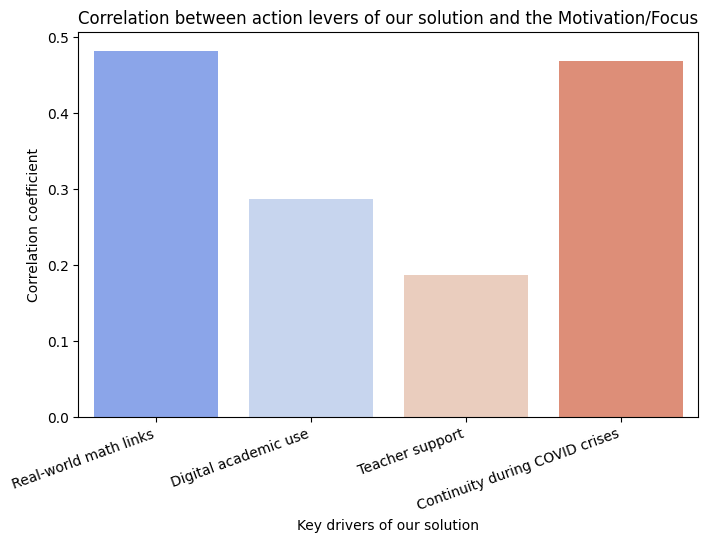

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

variables_interessantes = ["ST283","IC176","ST211","ST348"]

corrs = df[variables_interessantes].corrwith(df["concentration"])


labels = {
    "ST283": "Real-world math links",
    "IC176": "Digital academic use",
    "ST211": "Teacher support",
    "ST348": "Continuity during COVID crises"
}


plt.figure(figsize=(8,5))
sns.barplot(x=[labels[var] for var in corrs.index], y=corrs.values, palette="coolwarm")
plt.title("Correlation between action levers of our solution and the Motivation/Focus")
plt.xlabel("Key drivers of our solution")
plt.ylabel("Correlation coefficient")
plt.xticks(rotation=20, ha="right")
plt.show()

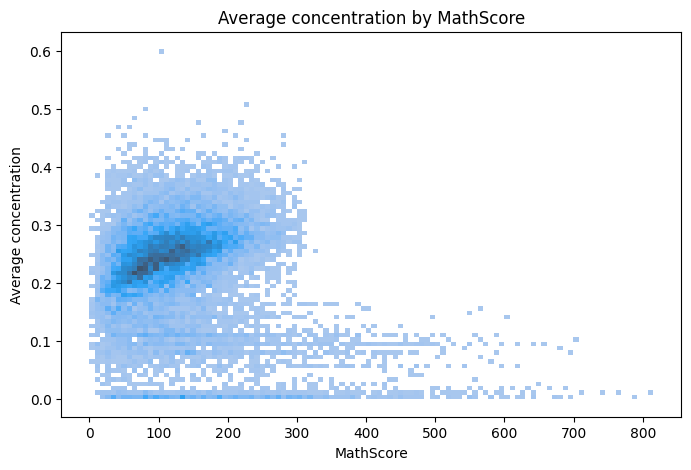

In [85]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Supposons que ton DataFrame s'appelle df et que y contient MathScore
df["MathScore"] = y["MathScore"]  # si MathScore est dans y

# Calcul de la moyenne de concentration par MathScore
mean_concentration = df.groupby("MathScore")["concentration"].mean().reset_index()

# Visualisation
plt.figure(figsize=(8,5))
sns.histplot(x="MathScore", y="concentration", data=mean_concentration)
plt.title("Average concentration by MathScore")
plt.xlabel("MathScore")
plt.ylabel("Average concentration")
plt.show()

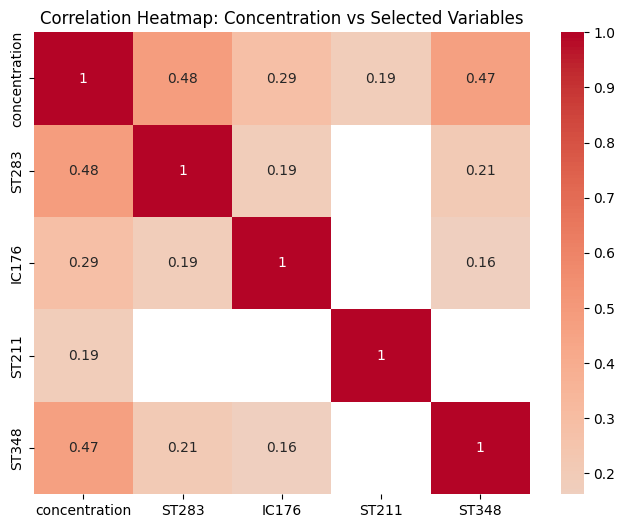

In [61]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Exemple : ton DataFrame s'appelle df
variables_interessantes = ["ST283","IC176","ST211","ST348"]

# On sélectionne la colonne 'concentration' + les variables
subset = df[["concentration"] + variables_interessantes]

# Calcul des corrélations (NaN ignorés automatiquement)
corr_matrix = subset.corr()

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap: Concentration vs Selected Variables")
plt.show()

##### Obvious limit of the analysis : our variable has been created using some of the variables in the dataset, so we can expect to find correlations between our variable and these variables, but it doesn't necessarily mean that these variables are the only ones that are correlated with our variable of interest, or that they are the most important ones. Nevertheless, they're relevant and can help us identify the key drivers of our solution, and to better understand the relationships between these variables and our variable of interest, which can help us to better target our solution and to better understand the mechanisms at play.


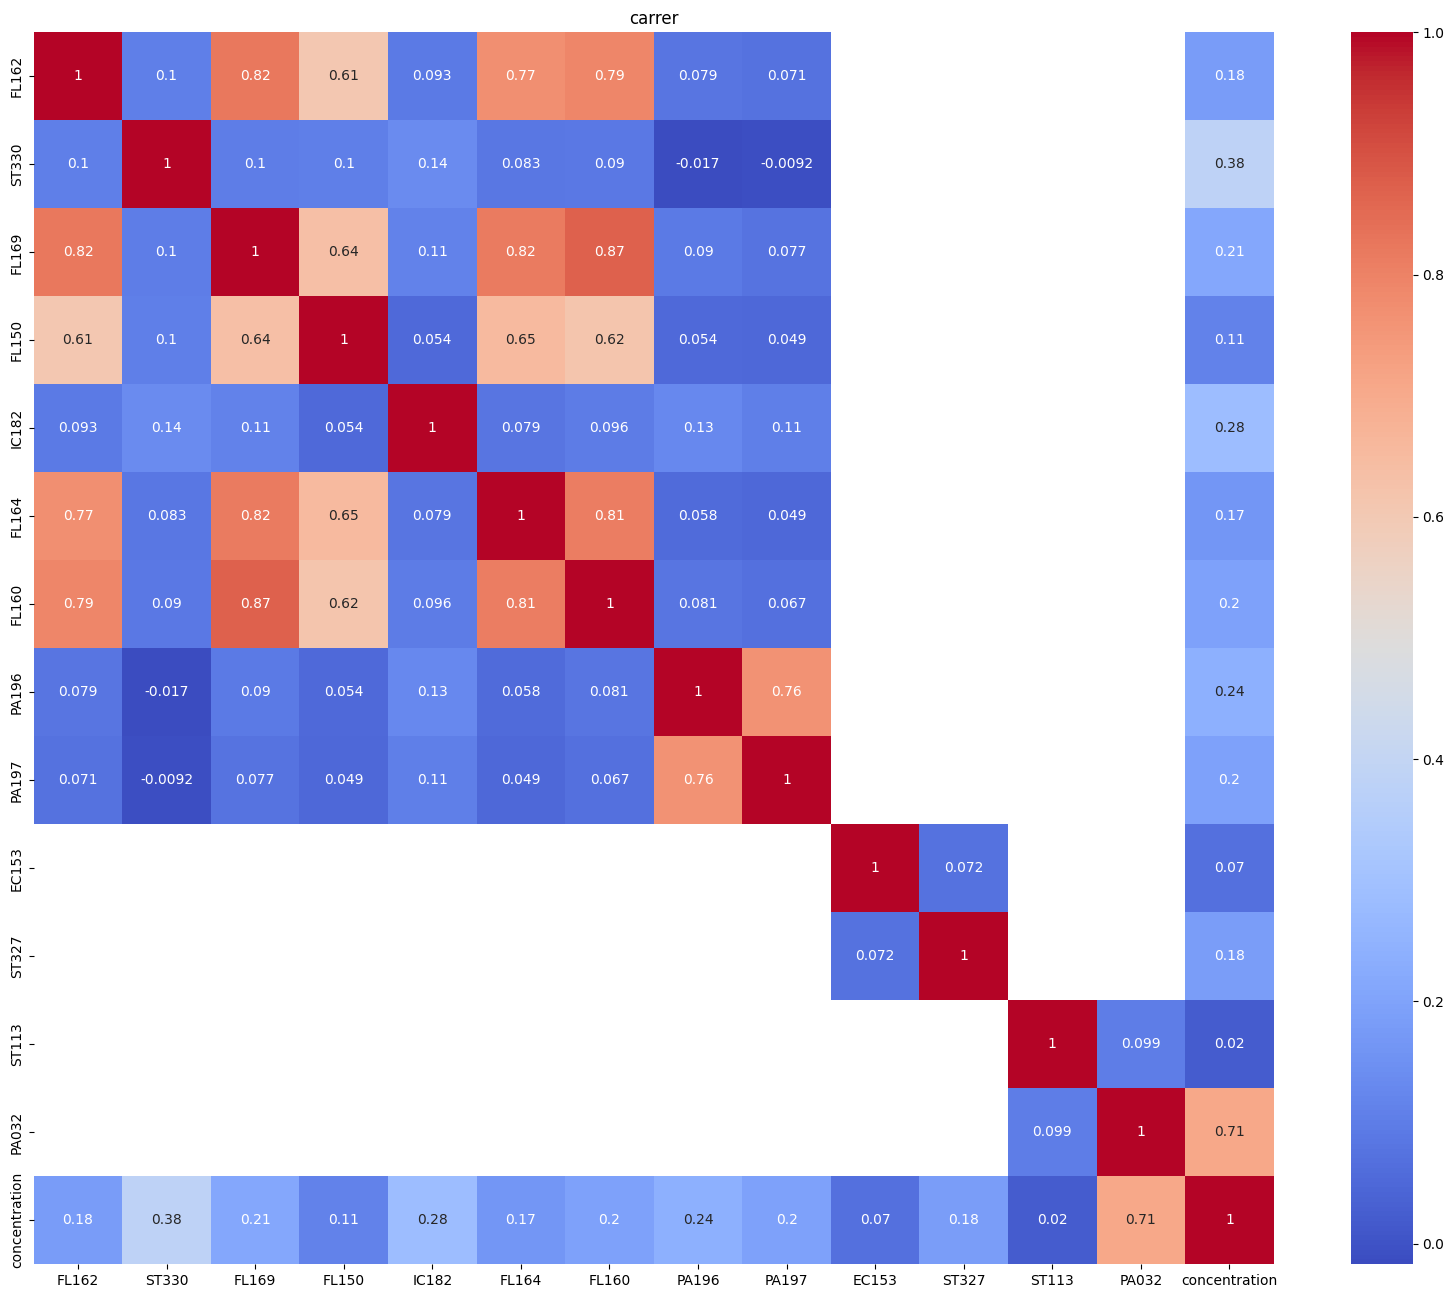

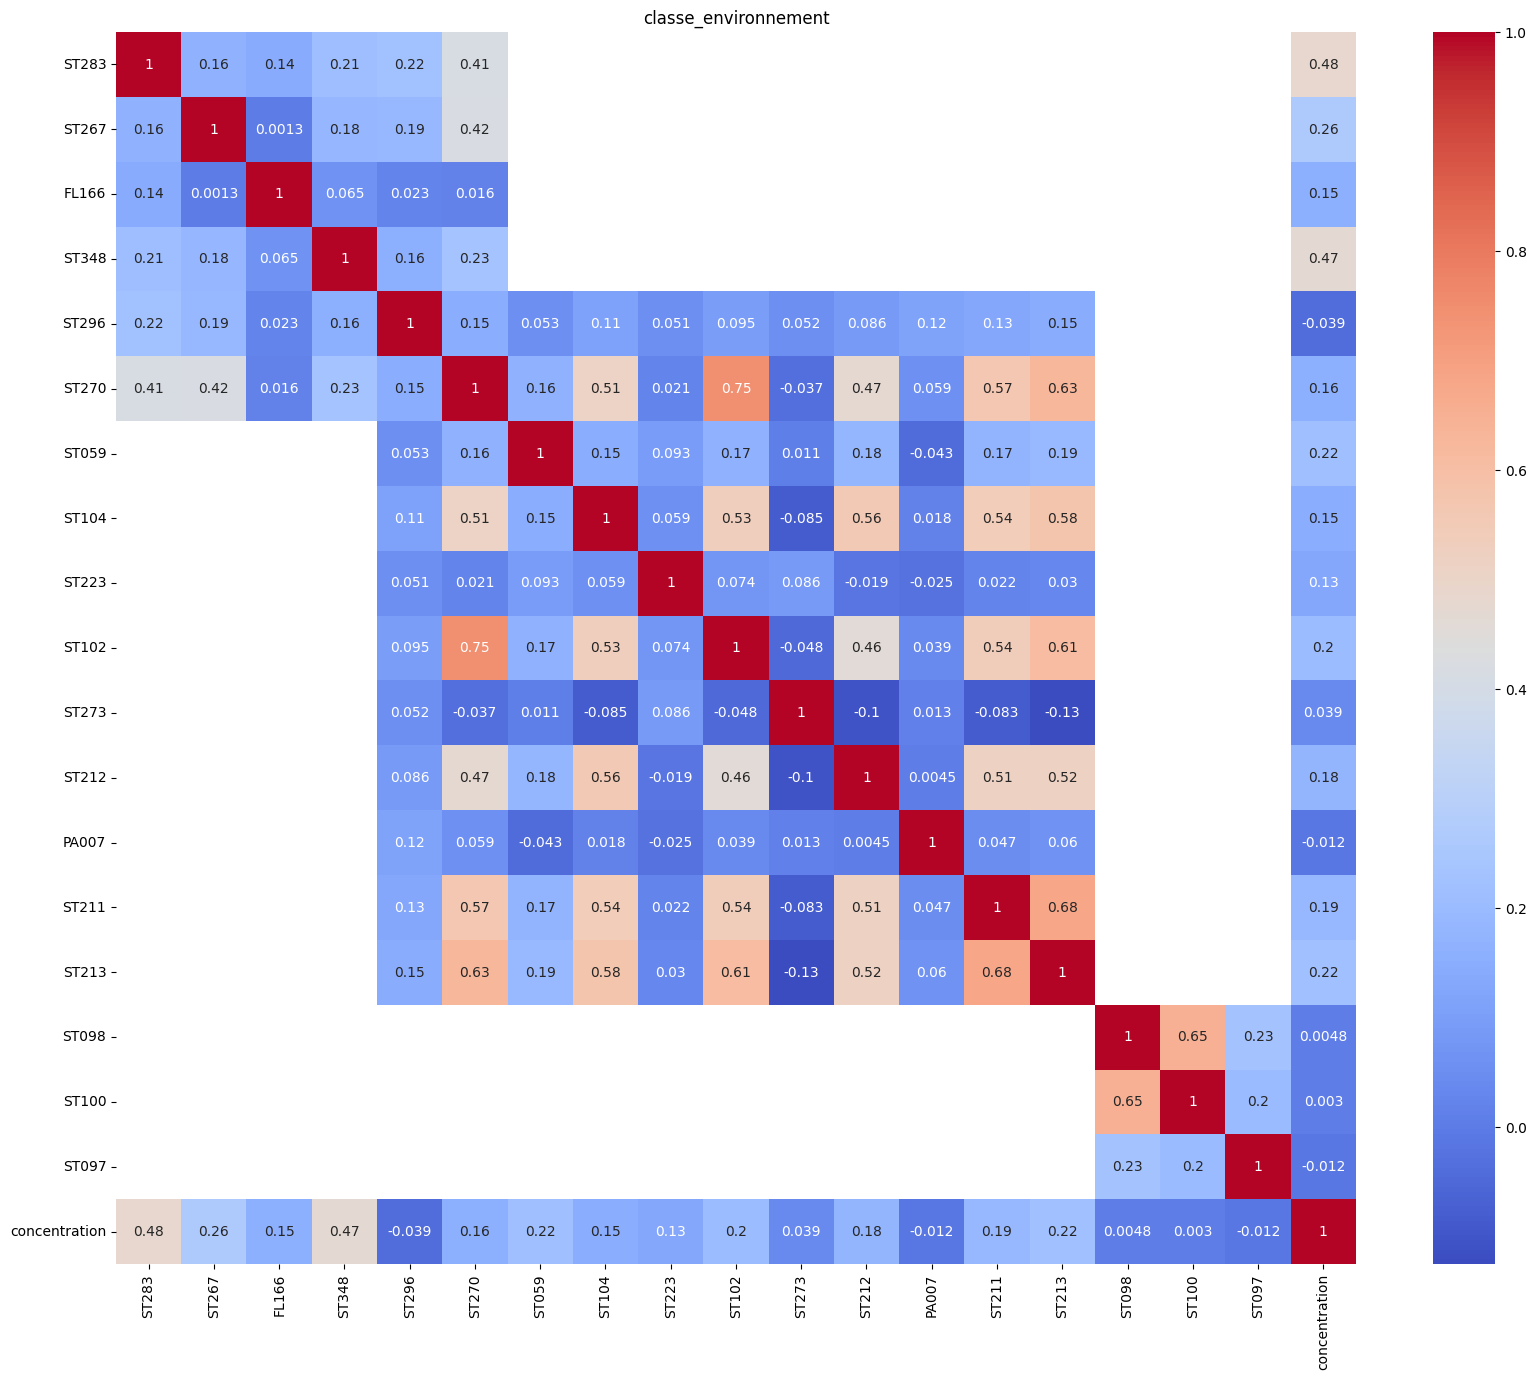

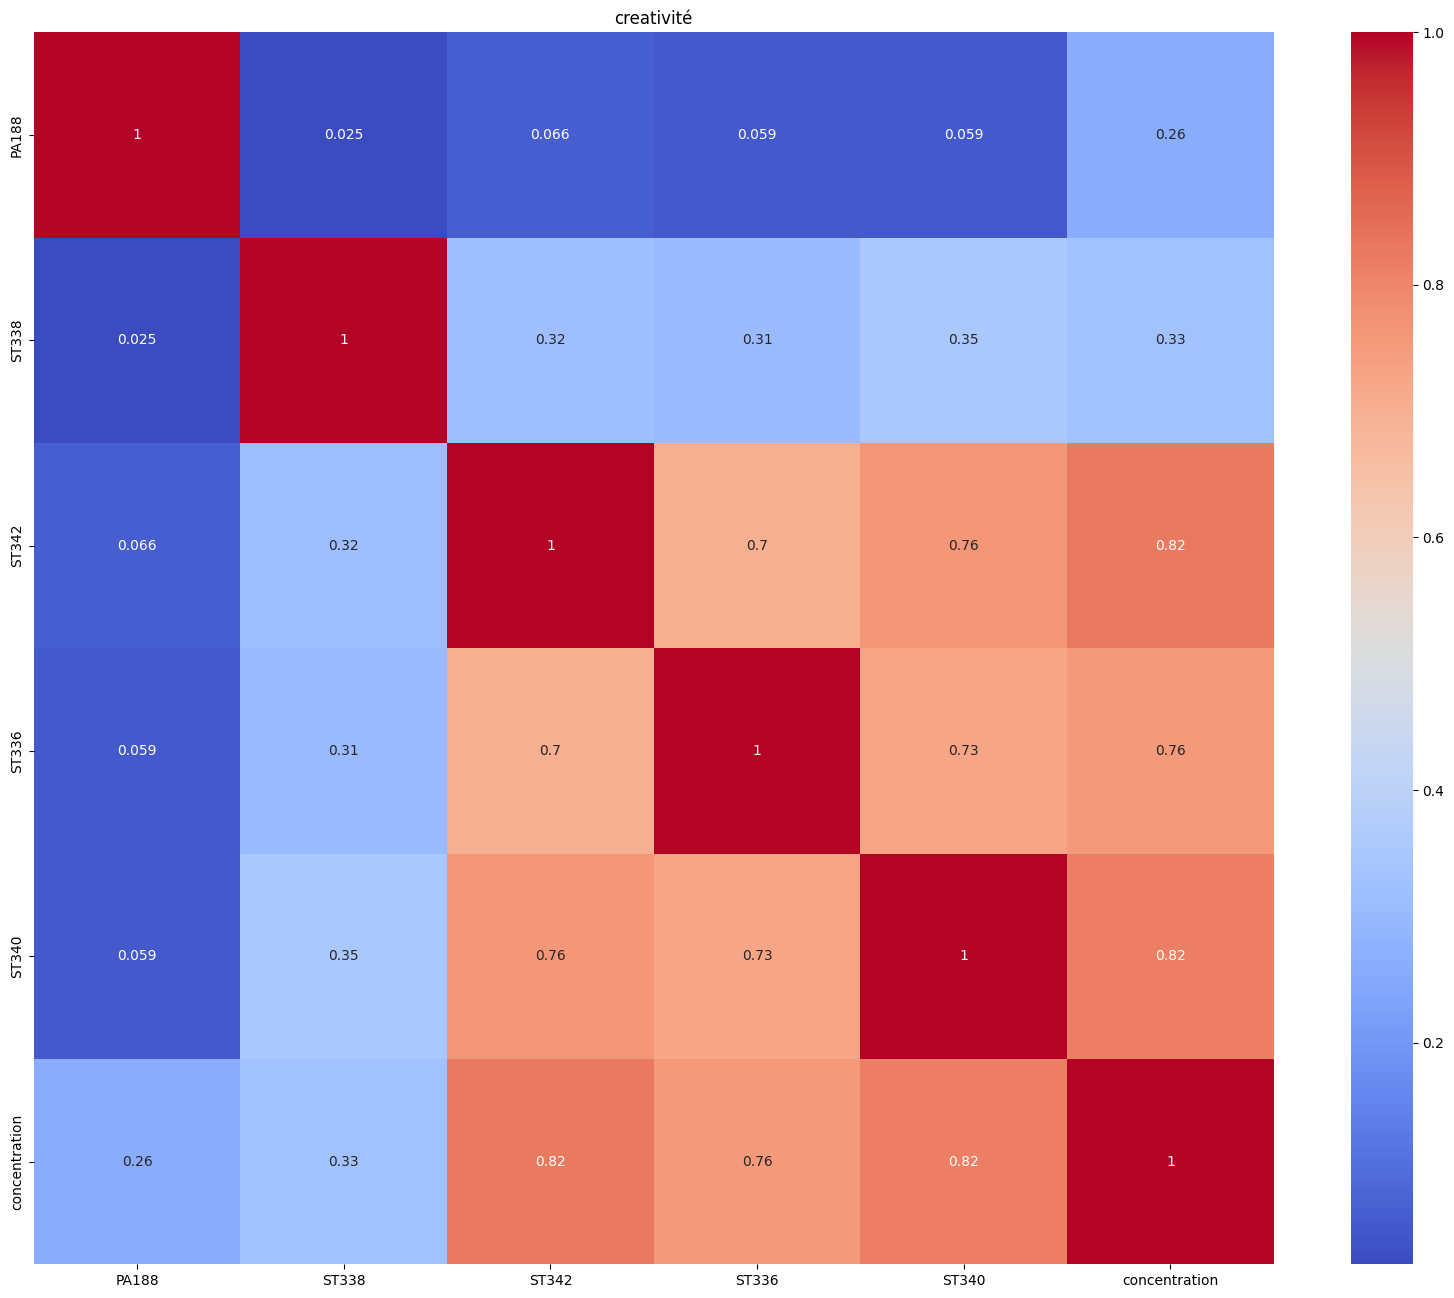

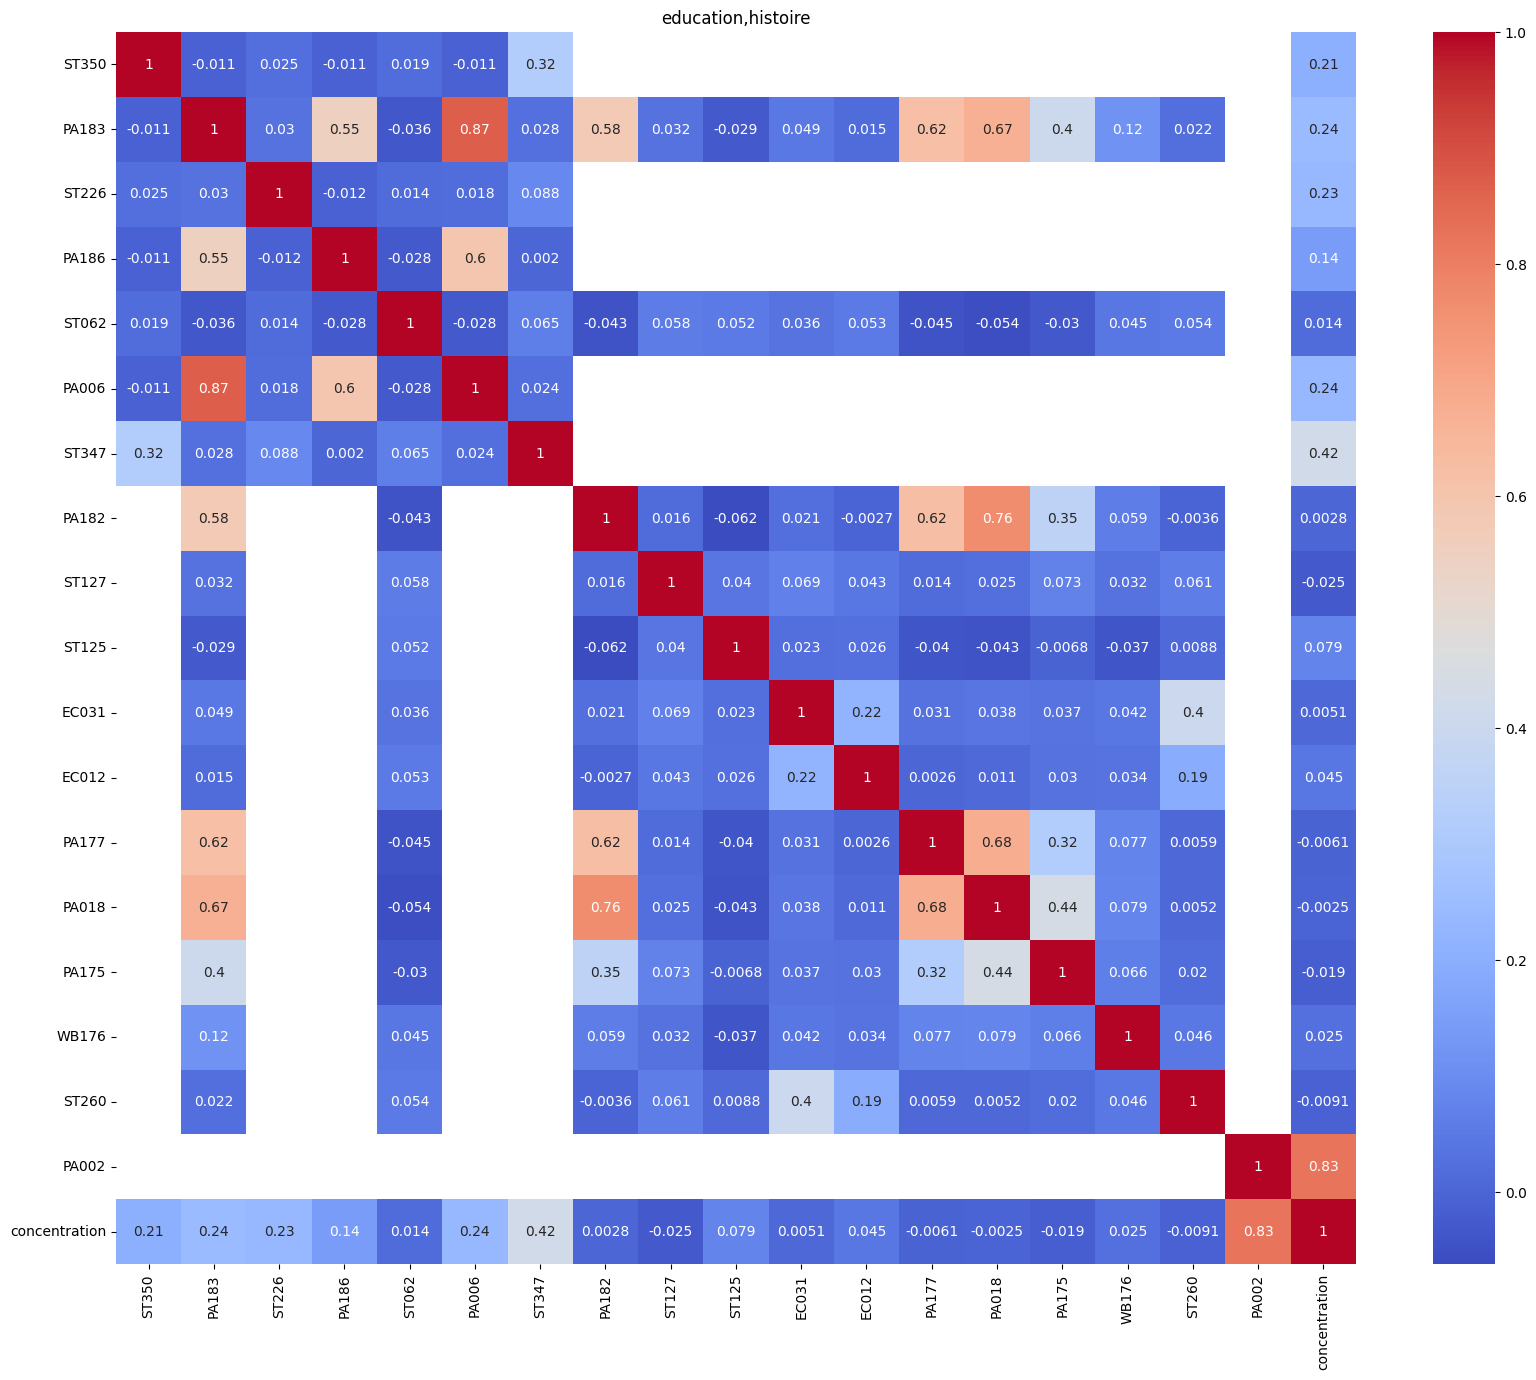

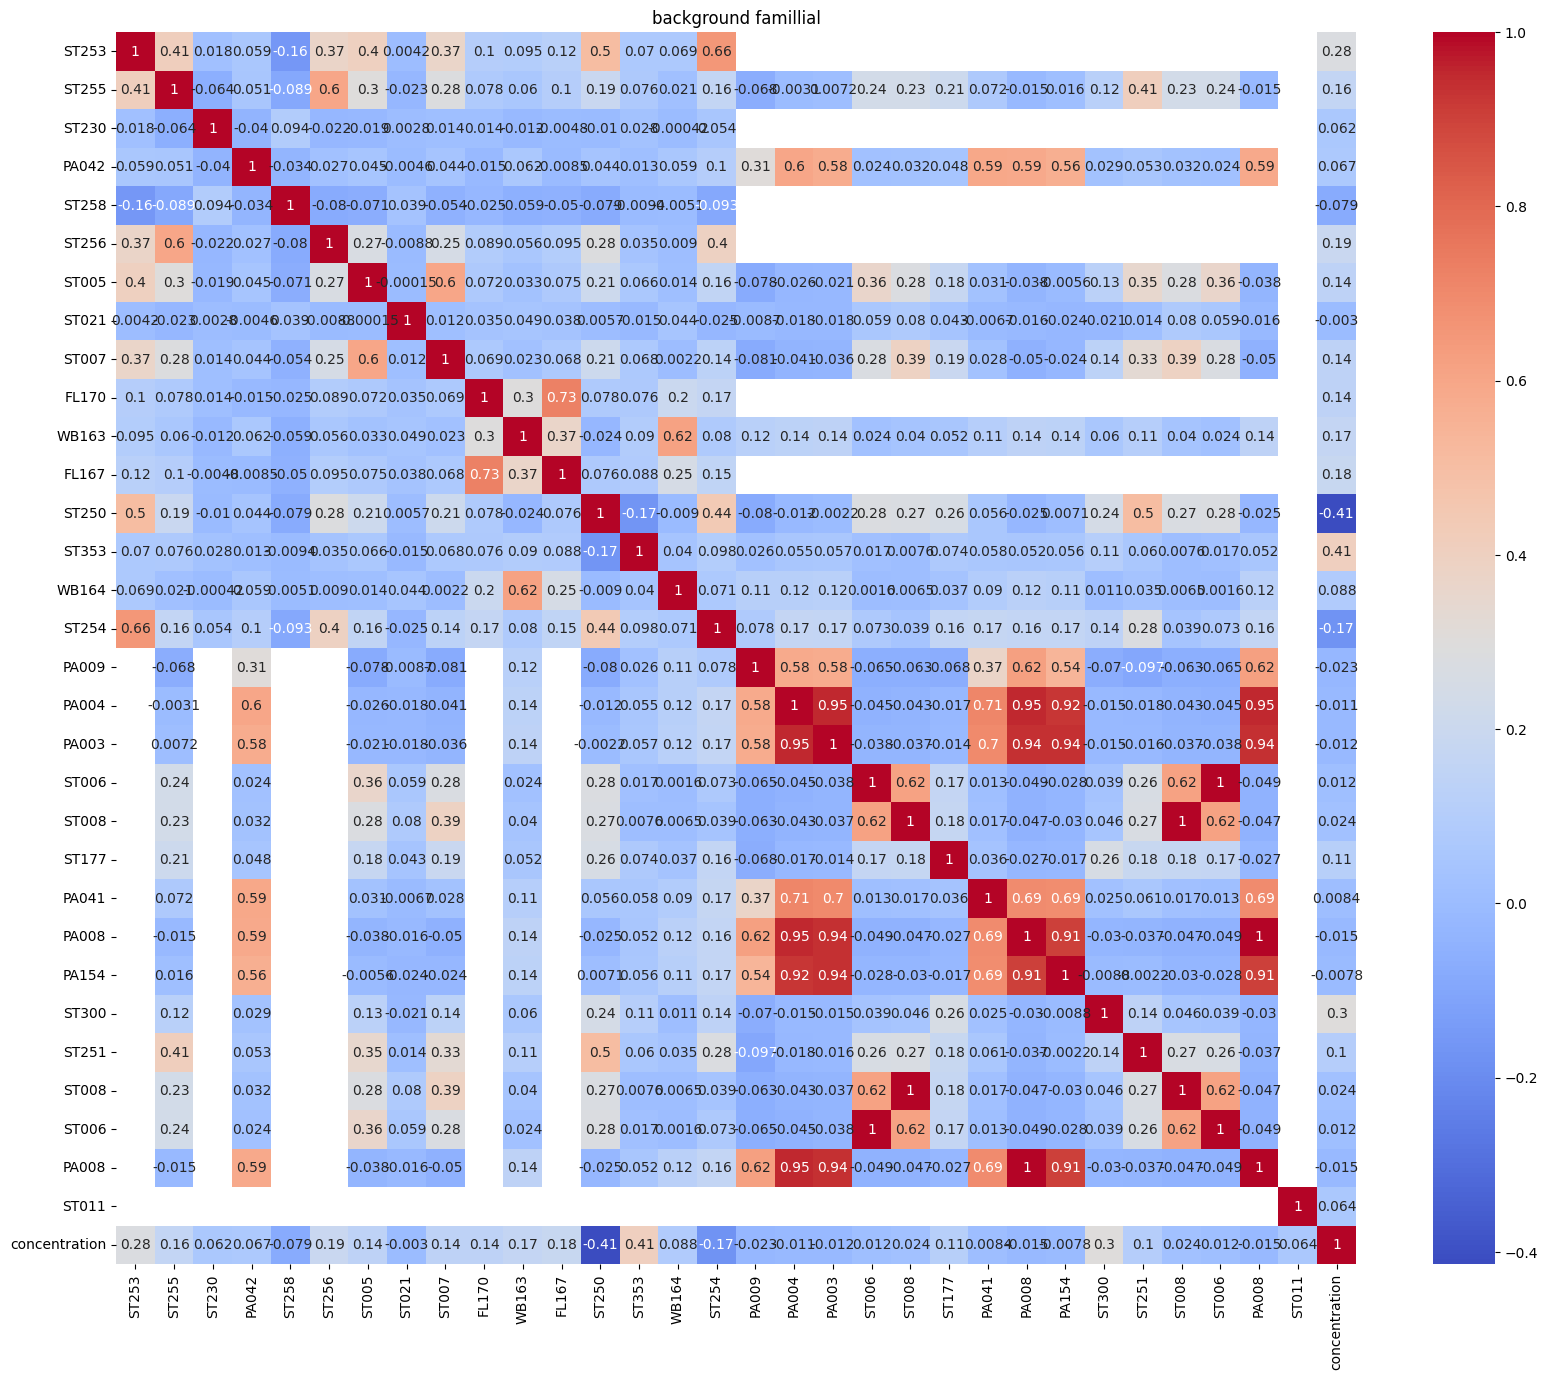

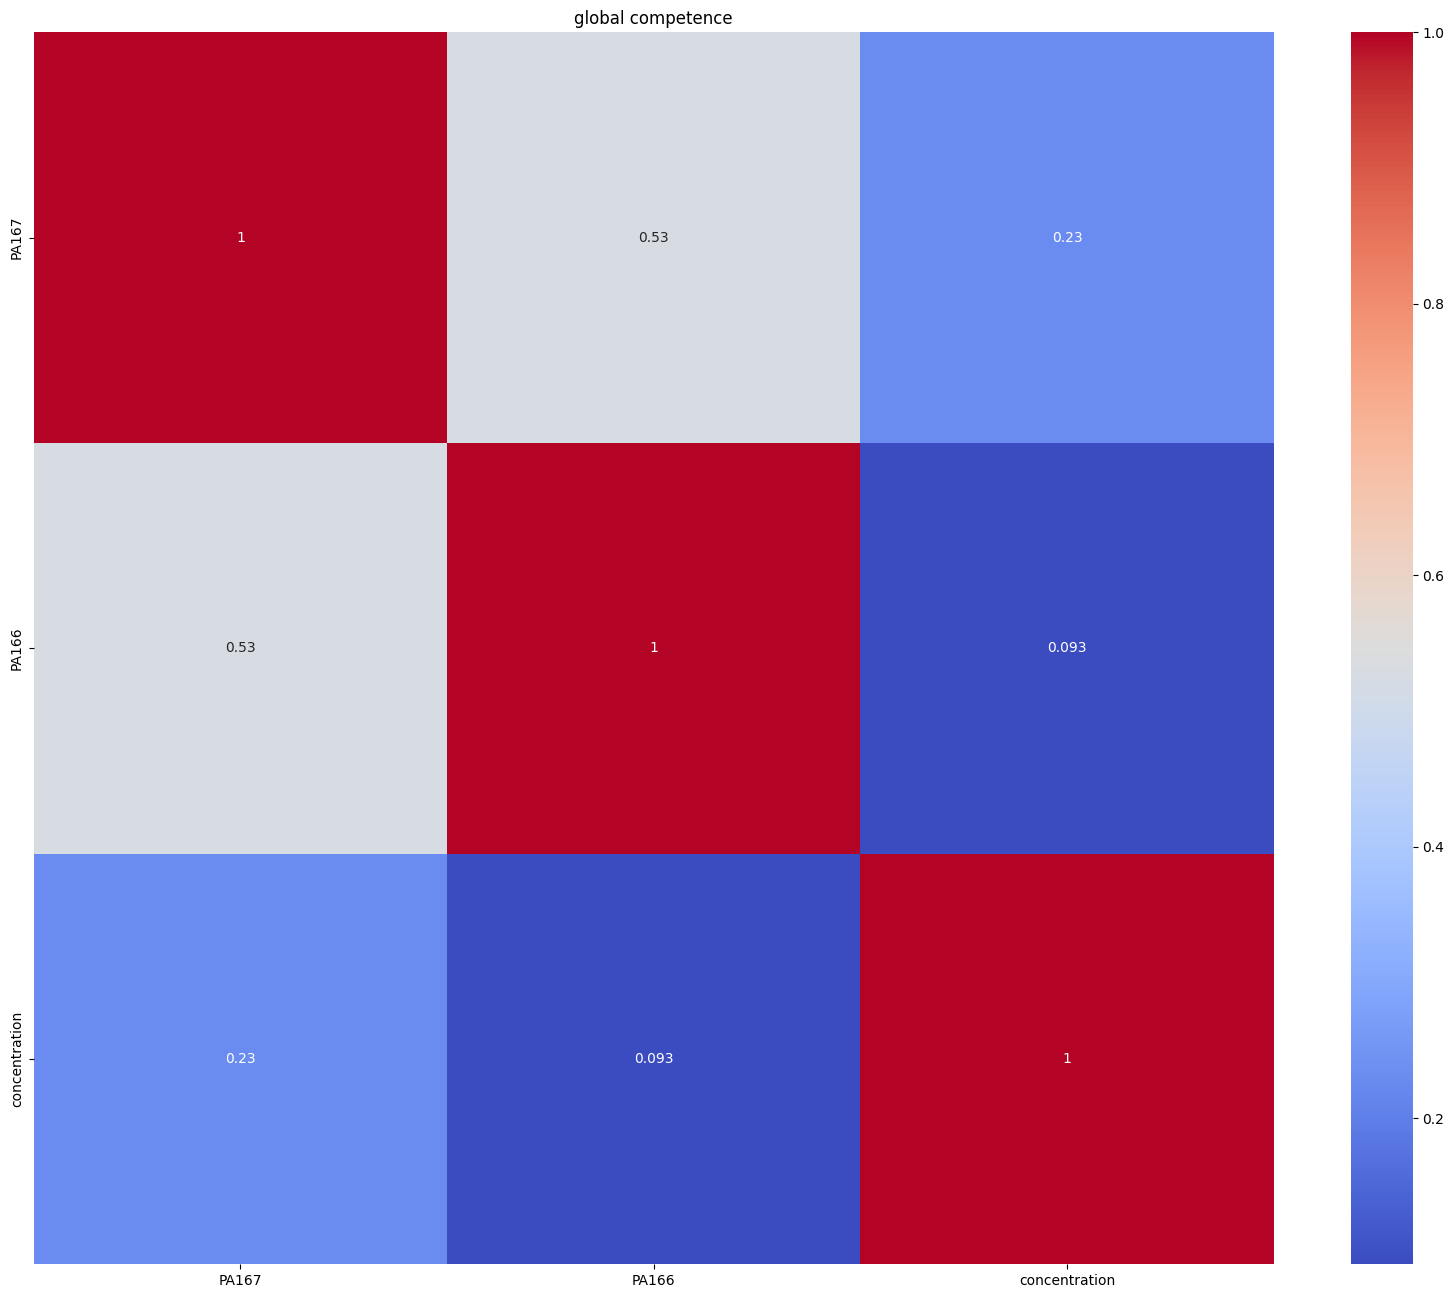

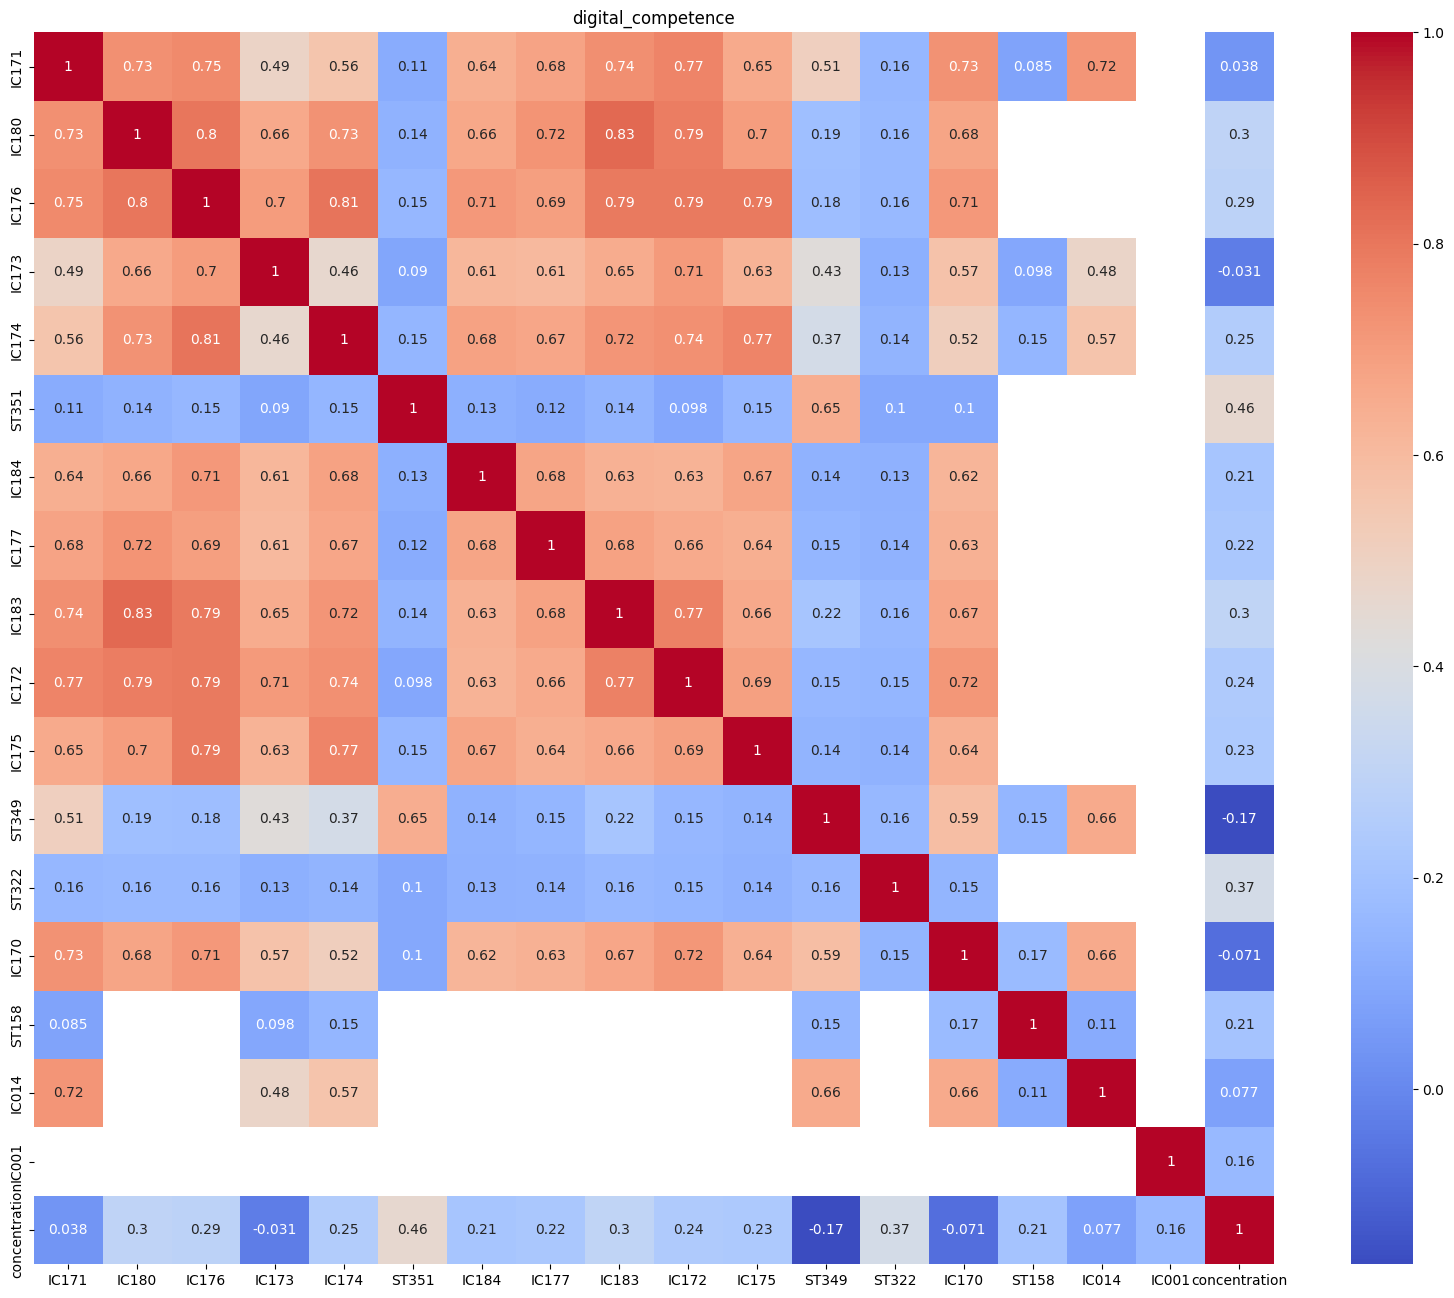

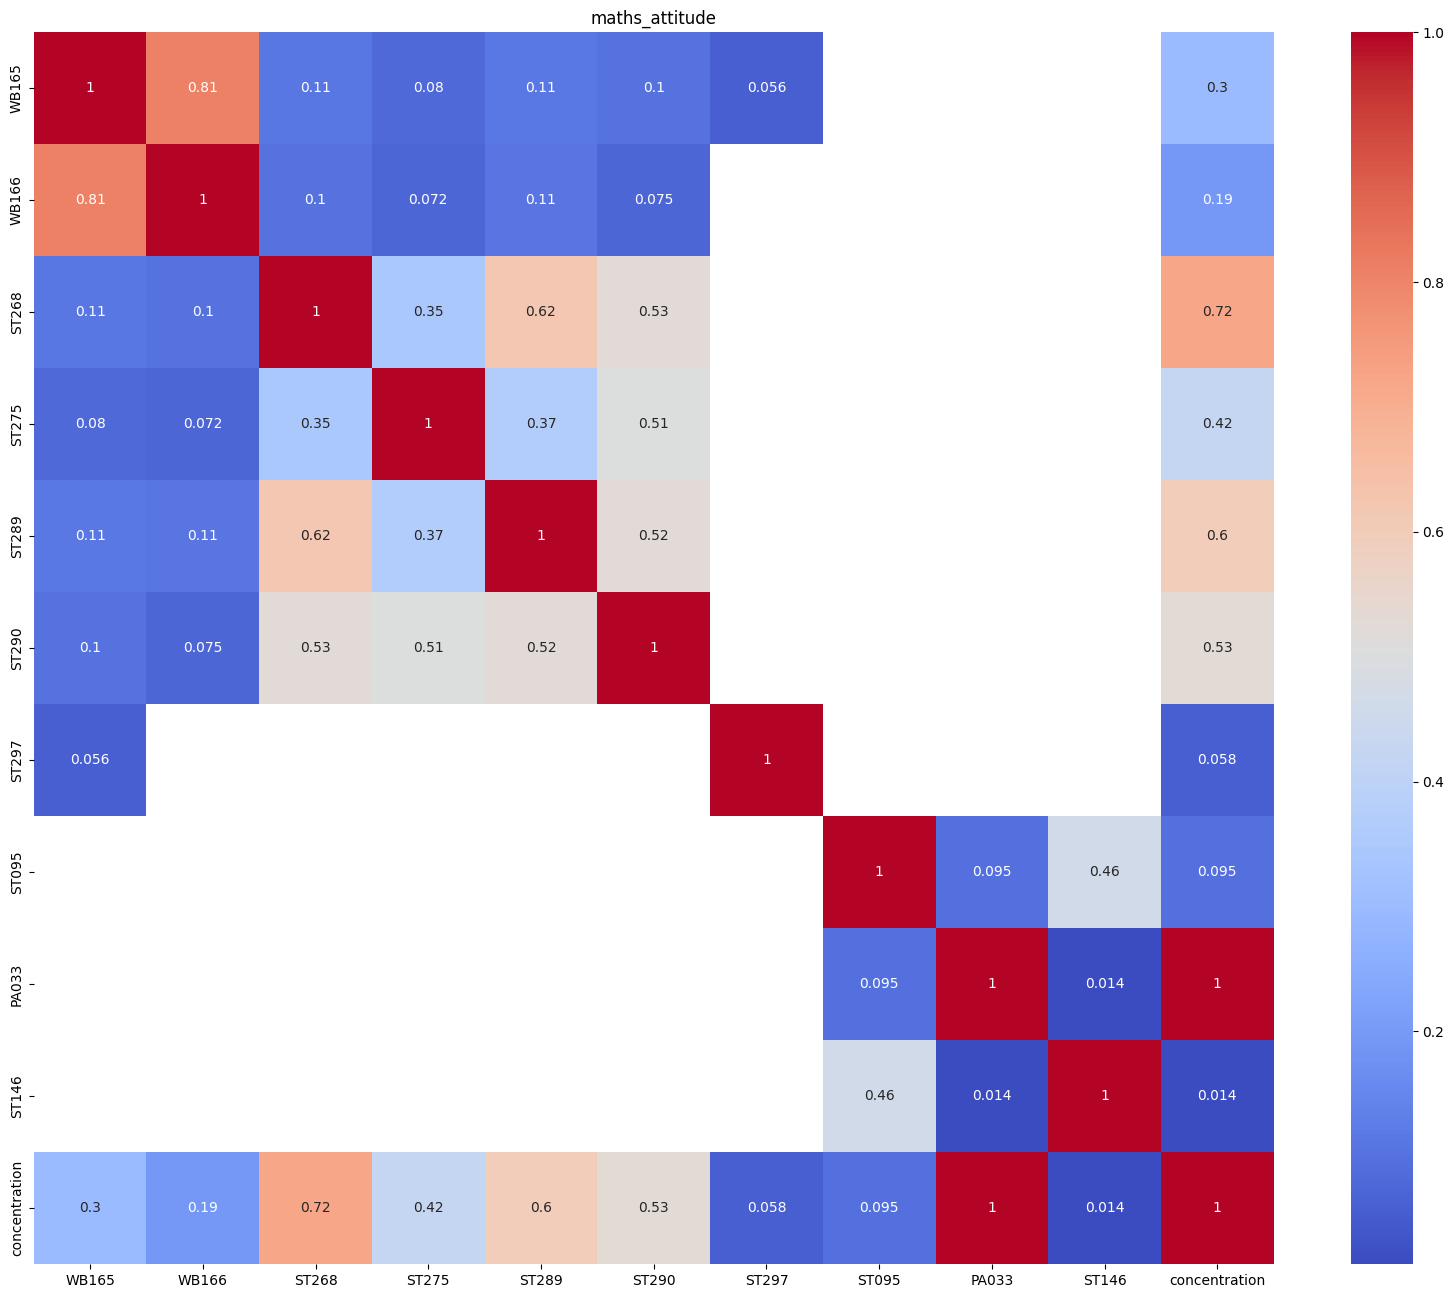

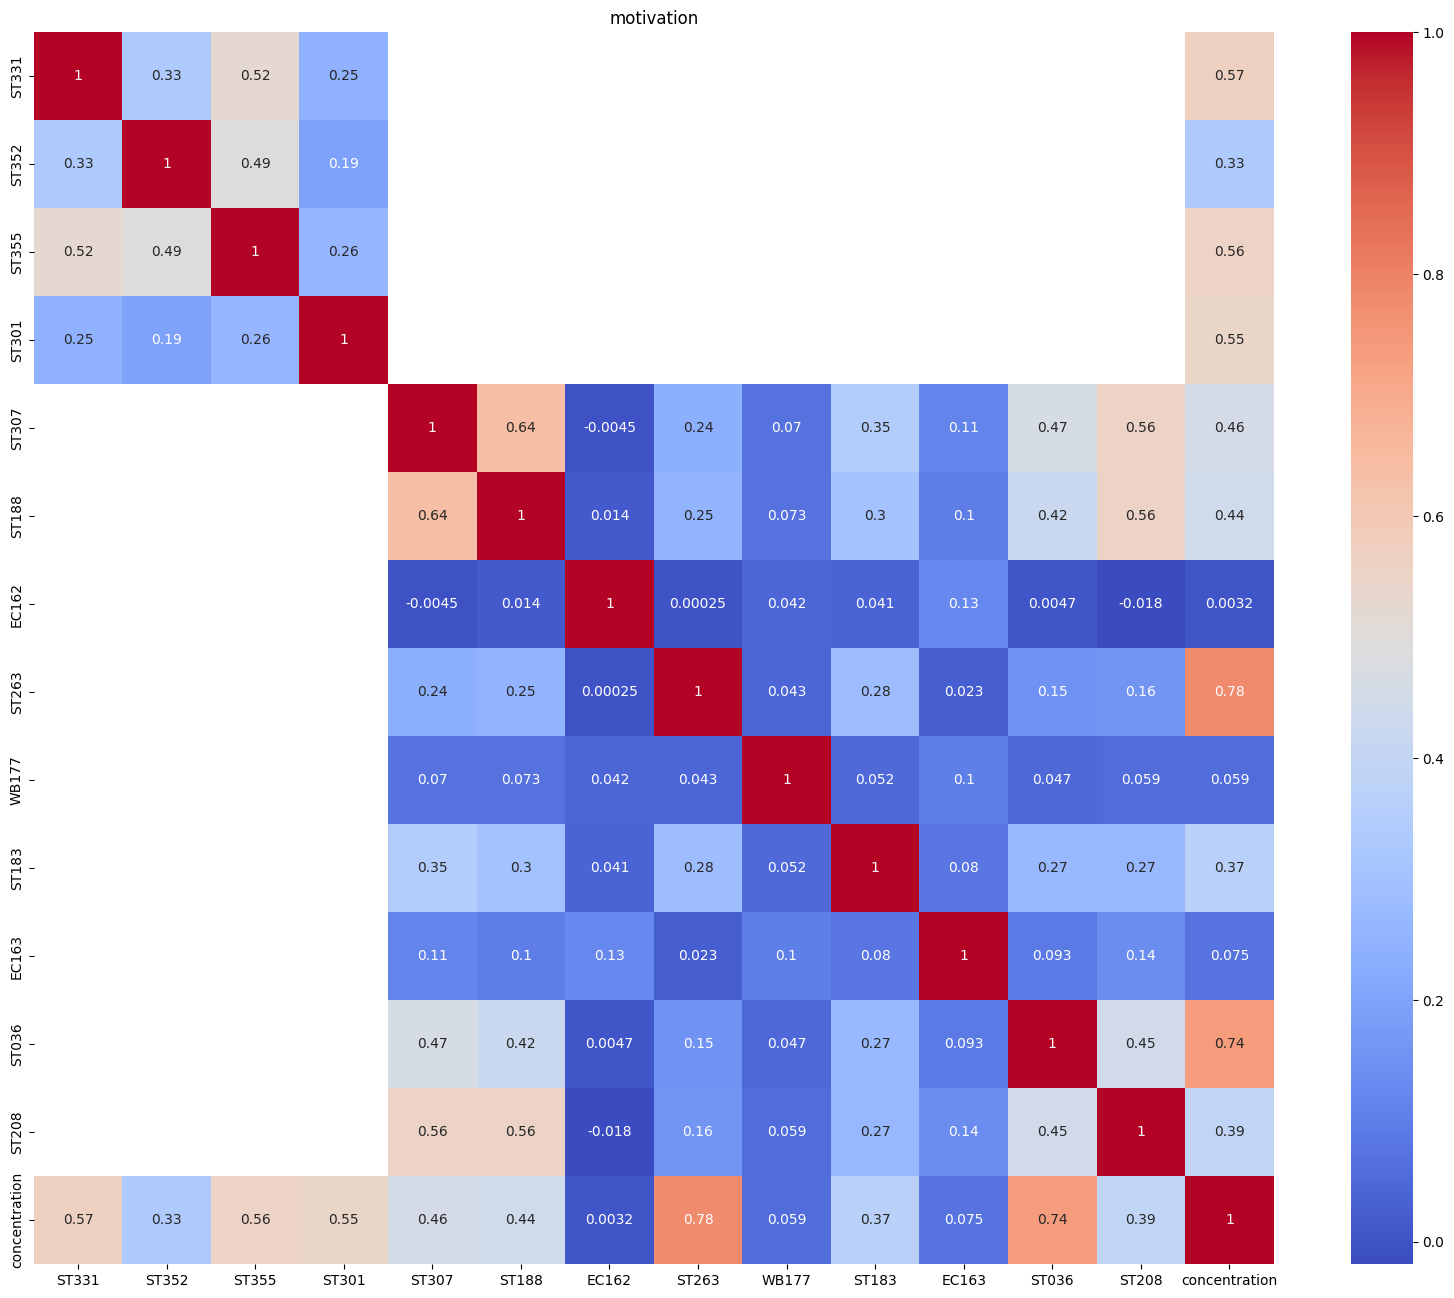

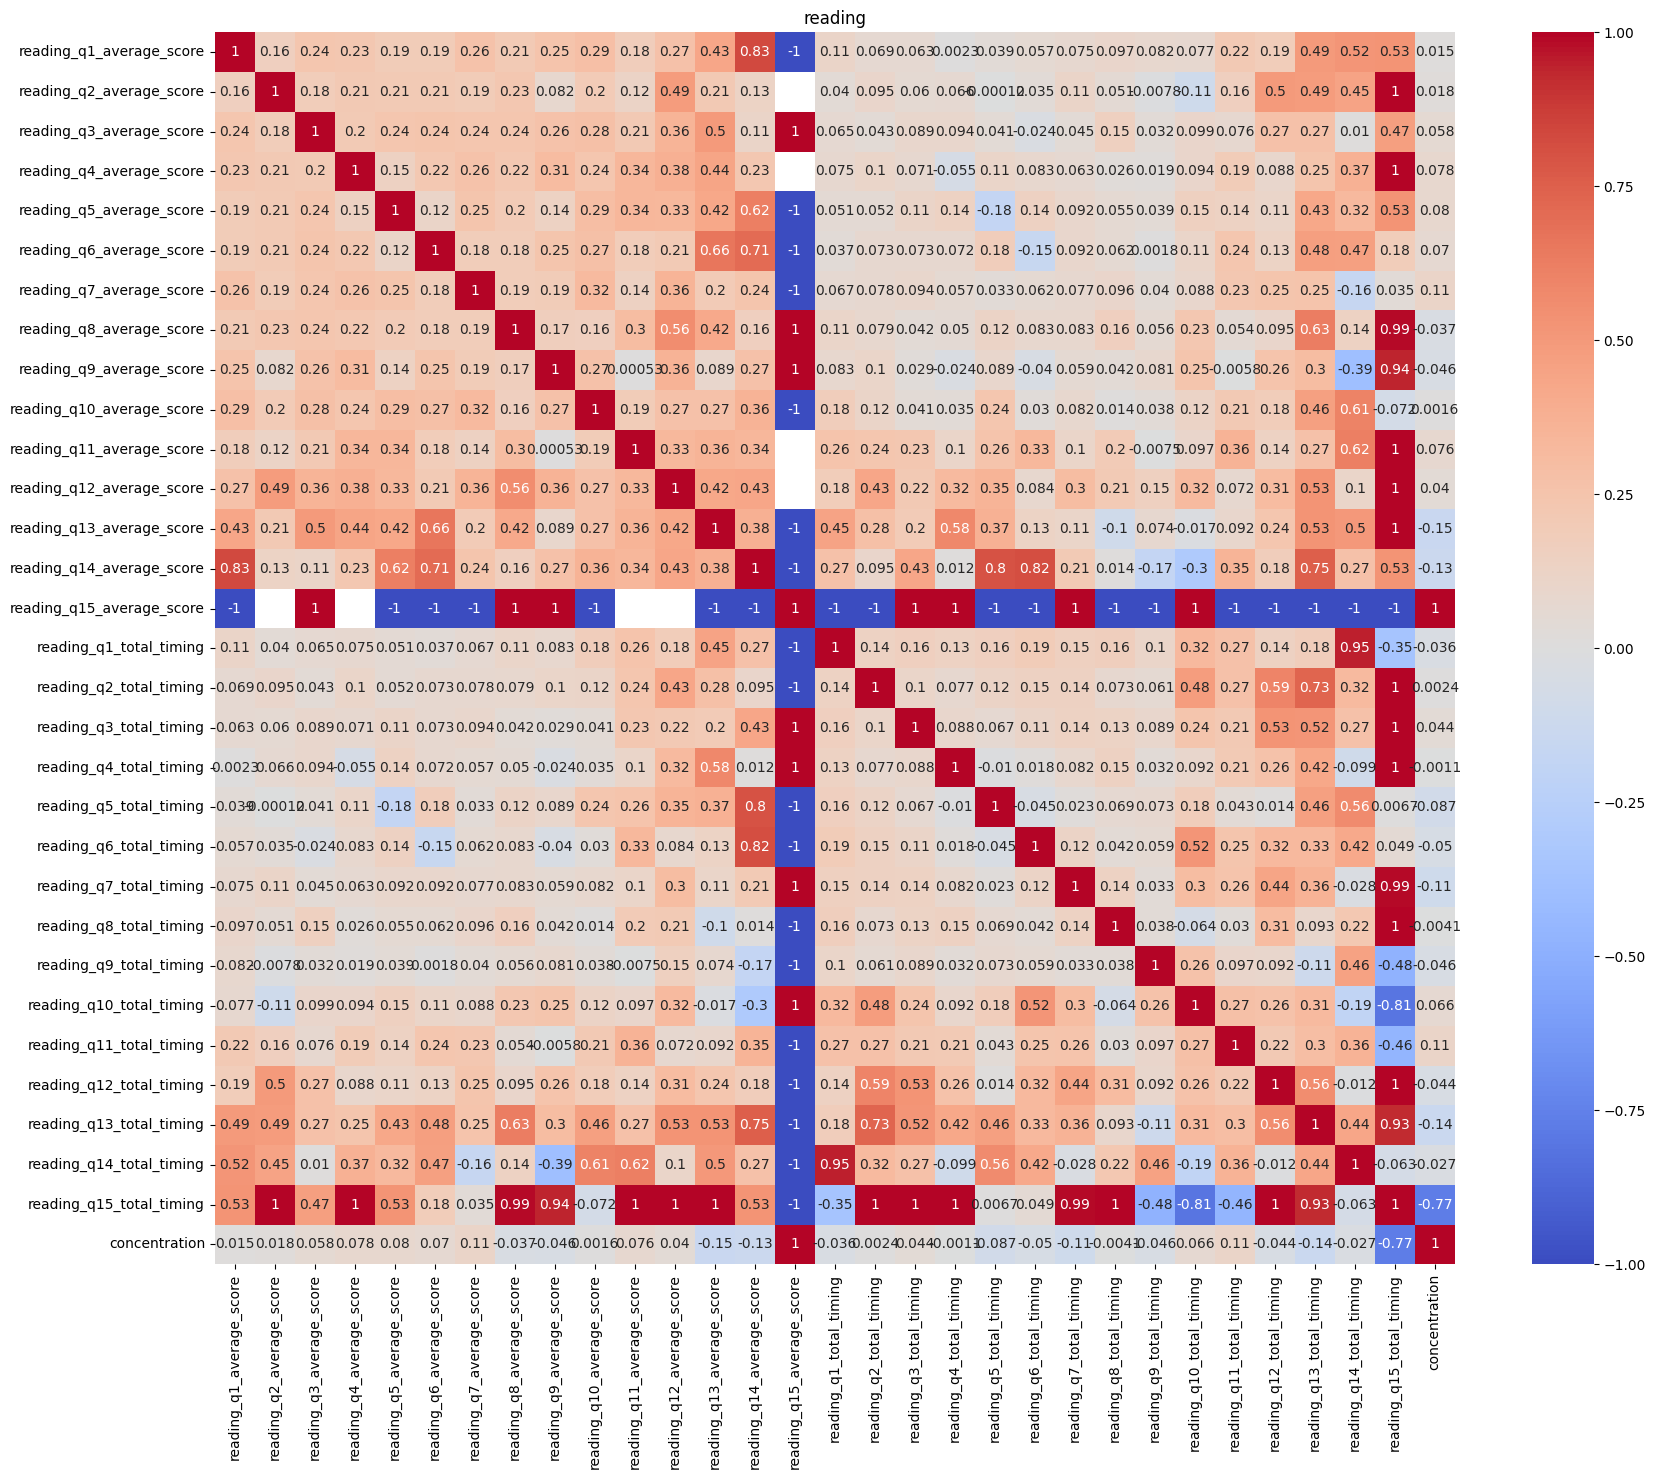

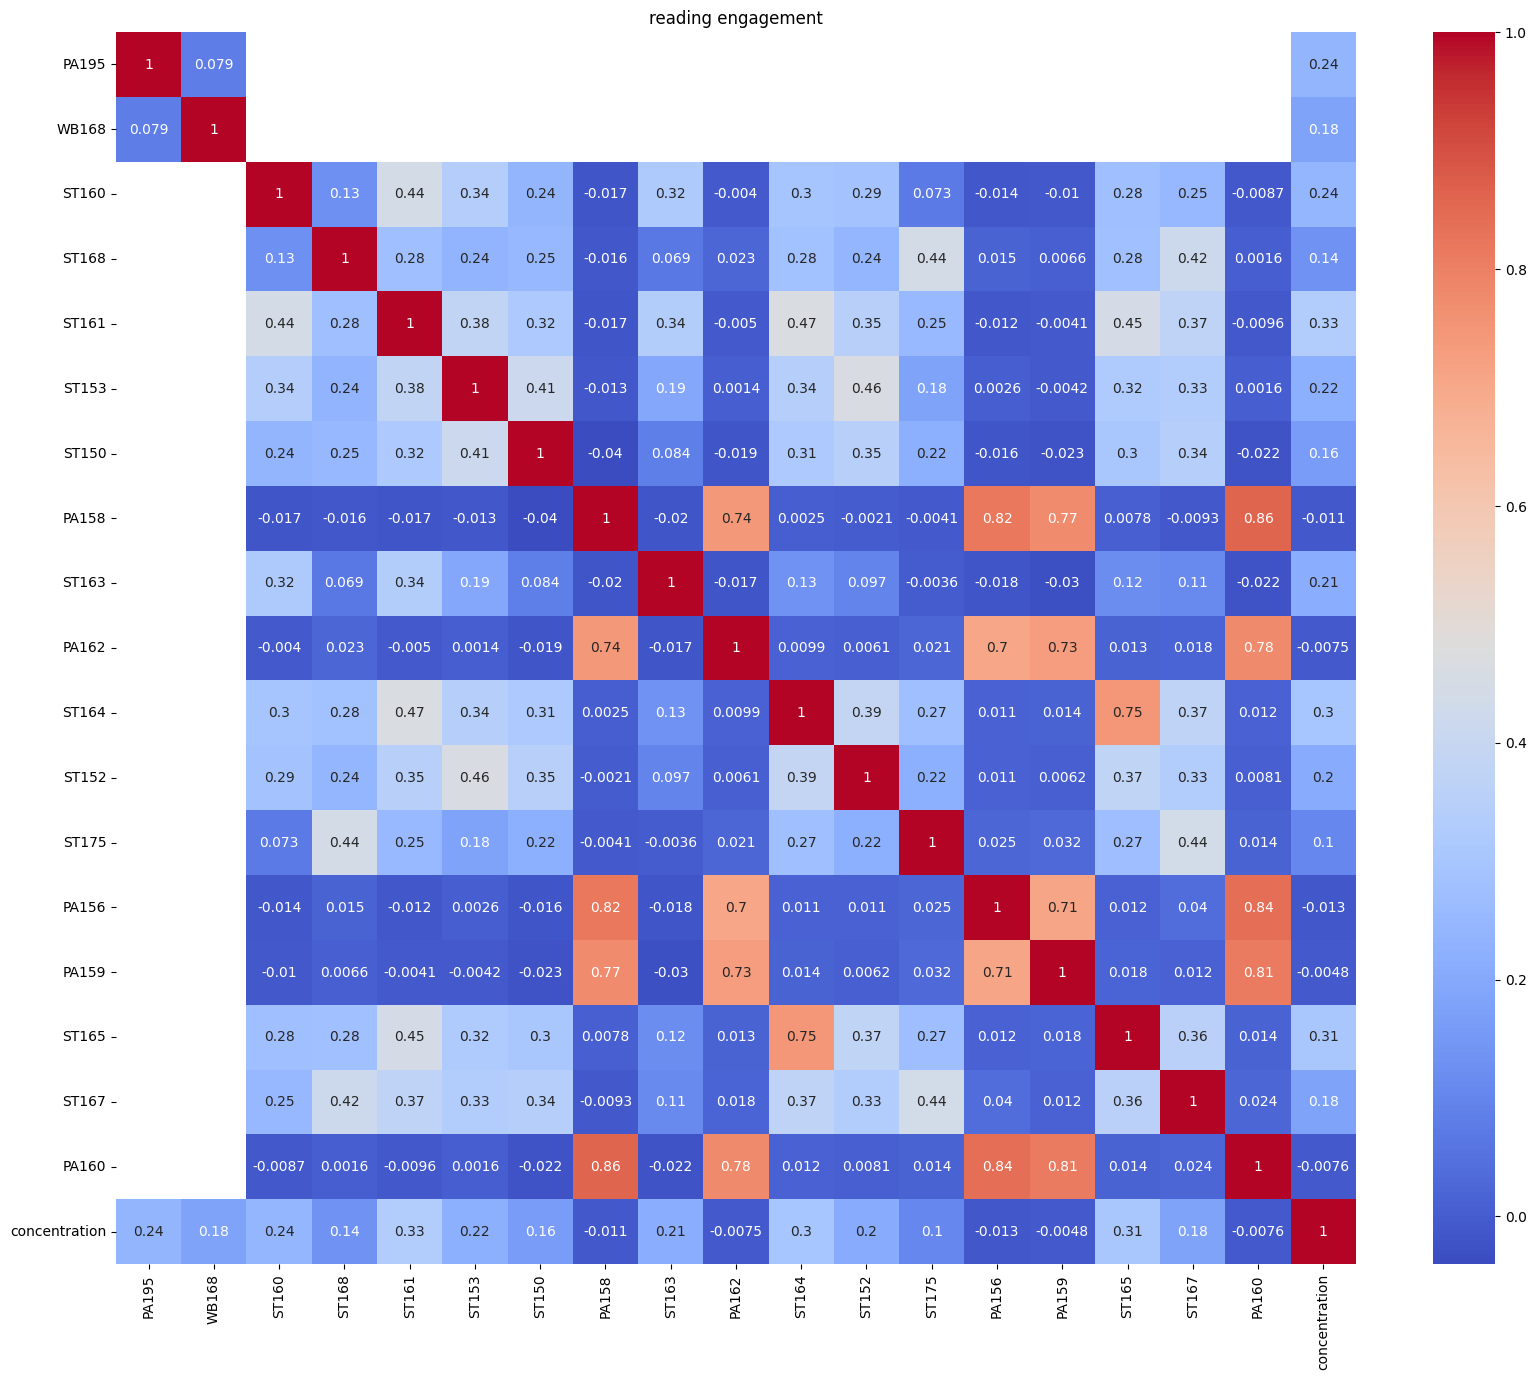

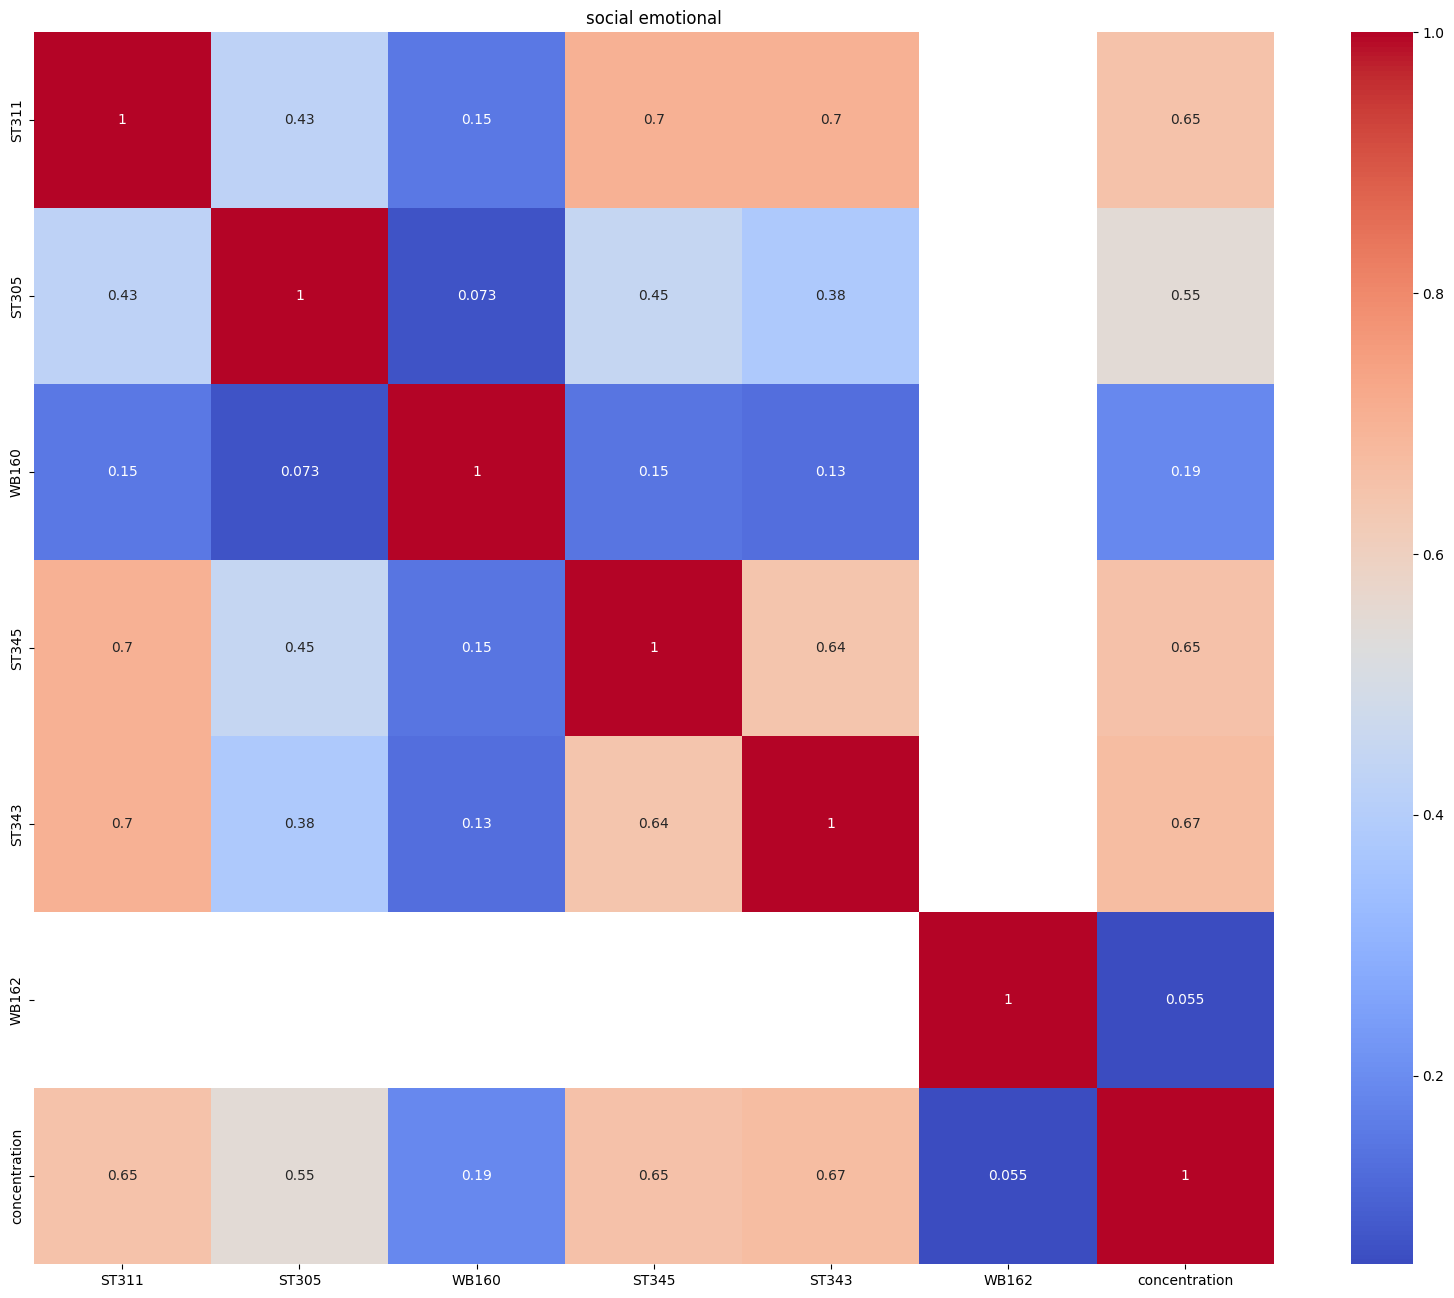

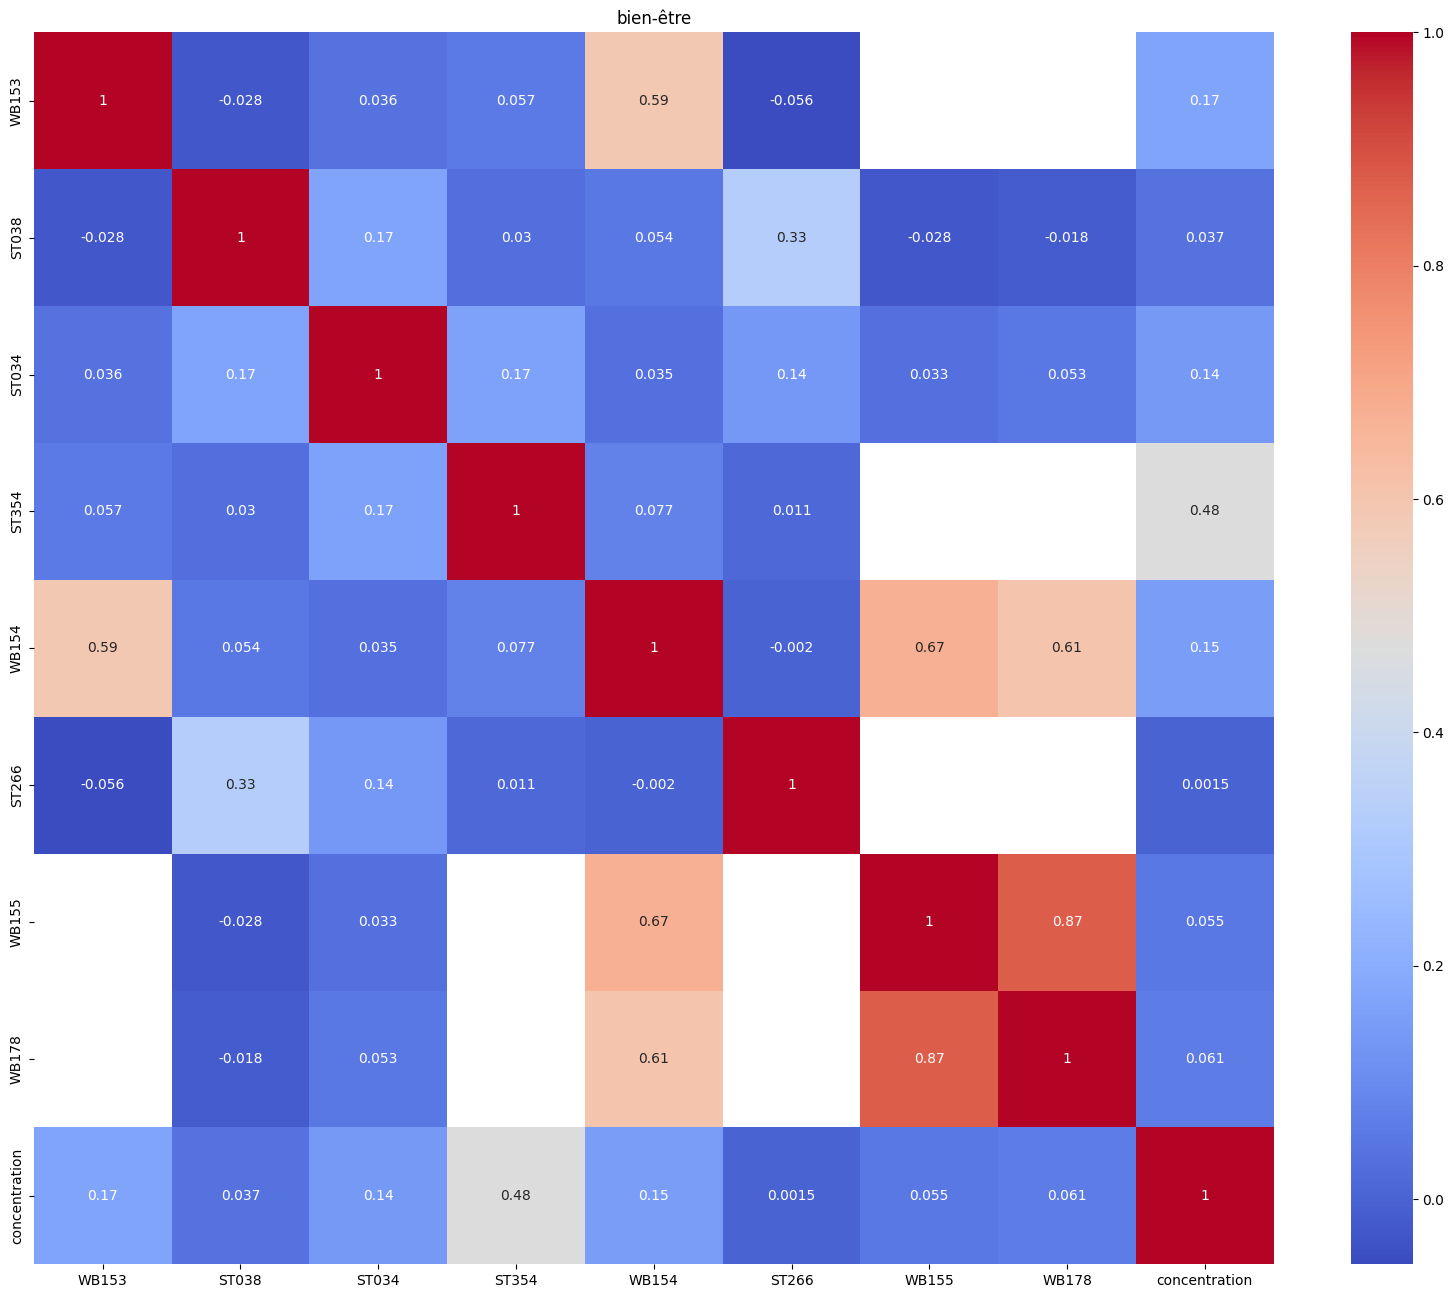

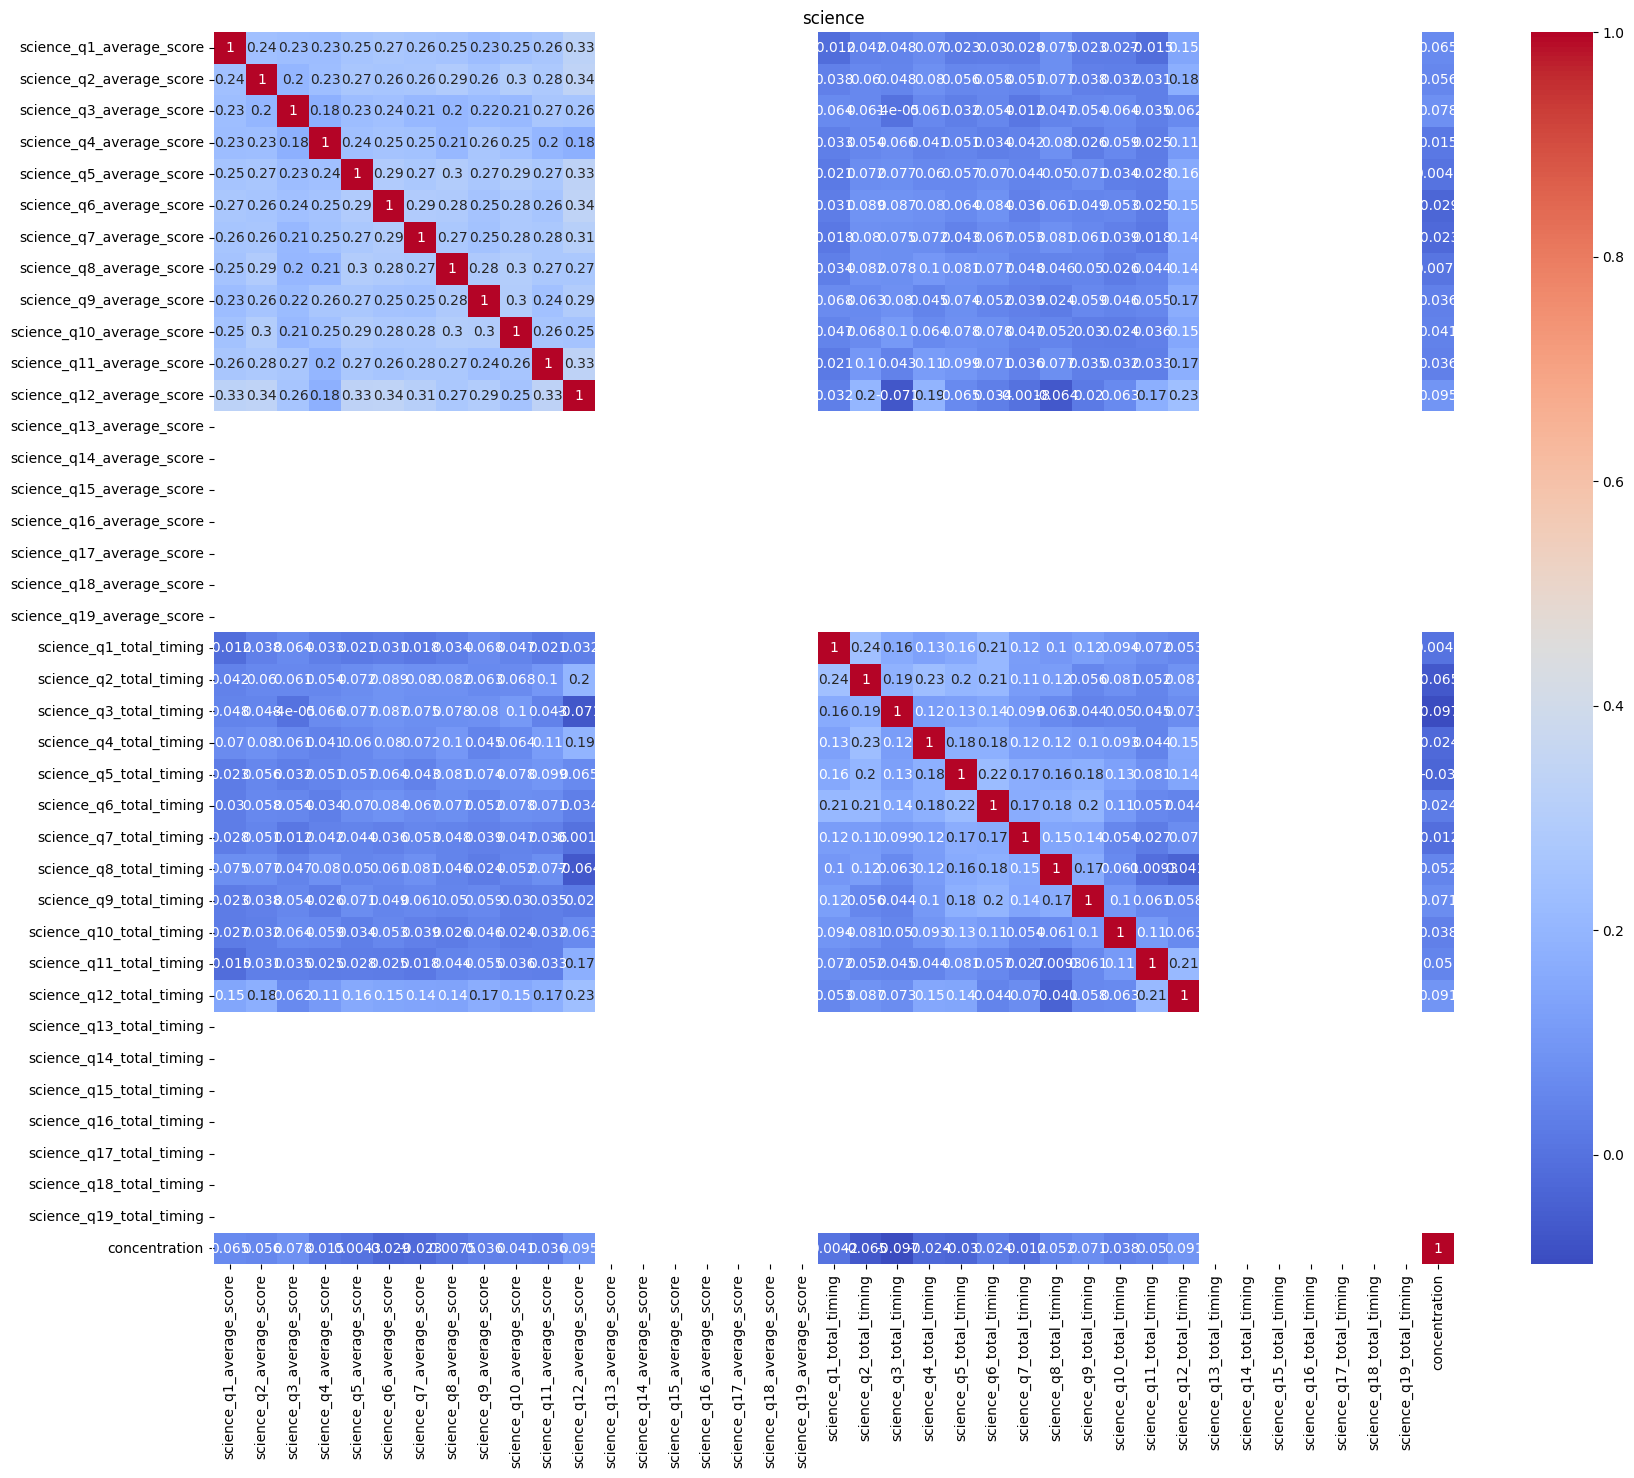

In [ ]:
#To check the correlation between our variable of interest and all other variables in each class 
for i in classes:
    car = donnees[i[1:]]
    car = (car - car.min()) / (car.max() - car.min())
    car["concentration"] = df['concentration']
    plt.figure(figsize=(20,16))
    corr = car.corr()
    sns.heatmap(corr, annot=True, cmap="coolwarm")
    plt.title(i[0])
    plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create bins for MathScore grouped by 10
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300, 310, 320, 330, 340, 350, 360, 370, 380, 390, 400, 410, 420, 430, 440, 450, 460, 470, 480, 490, 500]
labels = [f'{i}-{i+10}' for i in range(0, 500, 10)]

score_reading = df[['reading_q1_average_score','reading_q2_average_score','reading_q3_average_score','reading_q4_average_score',\
    'reading_q5_average_score','reading_q6_average_score','reading_q7_average_score','reading_q8_average_score',
    'reading_q9_average_score','reading_q10_average_score','reading_q11_average_score','reading_q12_average_score',
    'reading_q13_average_score','reading_q14_average_score','reading_q15_average_score']].mean(axis=1)
df['MathScore_bin'] = pd.cut(df['MathScore'], bins=bins, labels=labels, right=False)

# Calculate mean concentration for each bin
binned_data = df.groupby('MathScore_bin', observed=True)['concentration'].agg(['mean', 'count']).reset_index()

# Create the plot
plt.figure(figsize=(10, 6))
sns.barplot(data=binned_data, x='MathScore_bin', y='mean', palette='coolwarm')
plt.title('Average Concentration by MathScore Bins (10-point intervals)')
plt.xlabel('MathScore Range')
plt.ylabel('Average Concentration')
plt.show()

print(binned_data)

KeyError: ('reading_q1_average_score', 'reading_q2_average_score', 'reading_q3_average_score', 'reading_q4_average_score', 'reading_q5_average_score', 'reading_q6_average_score', 'reading_q7_average_score', 'reading_q8_average_score', 'reading_q9_average_score', 'reading_q10_average_score', 'reading_q11_average_score', 'reading_q12_average_score', 'reading_q13_average_score', 'reading_q14_average_score', 'reading_q15_average_score')

In [2]:
score_reading = (df['reading_q1_average_score']+df['reading_q2_average_score']+df['reading_q3_average_score']+df['reading_q4_average_score']+\
    df['reading_q5_average_score']+df['reading_q6_average_score']+df['reading_q7_average_score']+df['reading_q8_average_score']+\
    df['reading_q9_average_score']+df['reading_q10_average_score']+df['reading_q11_average_score']+df['reading_q12_average_score']+\
    df['reading_q13_average_score']+df['reading_q14_average_score']+df['reading_q15_average_score'])/15
score_reading.notna()

NameError: name 'df' is not defined

In [107]:
df['reading_q1_average_score']

0           NaN
1          0.25
2          0.75
3          1.00
4          0.00
           ... 
1172081    0.25
1172082     NaN
1172083    0.50
1172084    1.00
1172085    0.25
Name: reading_q1_average_score, Length: 1172086, dtype: float64